# Lennard-Jones with quantum effects via the path integral formalism

N atoms interacting through a Lennard-Jones potential (with cutoff at $r_c=3r_0$):
$$V=\sum_{1\le i<j\le N}V(r_{ij})\quad\text{with}\quad V(r_{ij})=\begin{dcases}
\quad 4\epsilon\left(\left(\frac{r_0}{r_{ij}}\right)^{12}-\left(\frac{r_0}{r_{ij}}\right)^{6}\right) & \text{ if } r_{ij}\le r_c \\
\quad 0 & \text{ if } r_{ij}\gt r_c
\end{dcases}$$
where $r_{ij}=r_i-r_j$

With quantum effects in the Path Integral formalism. P replicas for each nucleus with a harmonic potential:
$$Q_P(\beta)=\frac{mP}{2\hbar^2\beta^2}\sum_{i=1}^P (x_i-x_{i+1})^2$$
where $x_i=(x_{i,1}, y_{i,1}, ... x_{i,N}, y_{i,N})$ is the set of $N$ coordinates across the replica $i$.

Total potential:
$$V_P(\beta)=Q_P(\beta)+\frac{1}{P}\sum_{i=1}^P V(x_i)$$

(Configurational) partition function:
$$Z_c(\beta)=\int...\int {\rm d}x_1...{\rm d}x_P \exp(-\beta V_P(\beta))

| $\rm Atom$ | $\rm He$ | $\rm Ne$ | $\rm Ar$ | $\rm Kr$ | $\rm Xe$ |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **$r_0\ {\rm (Å)}$** | $2.64$ | $2.74$ | $3.40$ | $3.65$ | $3.98$ |
| **$\epsilon\ {\rm (meV)}$** | $0.9$ | $3.1$ | $10.4$ | $14.0$ | $20.0$ |

**Table 4.1:** Lennard-Jones parameters for rare gases. Values from [136, 137].

| $\rm Atom$ | $^3{\rm He}$ | $^4{\rm He}$ | ${\rm Ne}$ | ${\rm Ar}$ | ${\rm Kr}$ | ${\rm Xe}$ |
| :--- | :--- | :--- | :--- | :--- | :--- | :--- |
| **$\Lambda$** | $3.1$ | $2.6$ | $0.59$ | $0.19$ | $0.10$ | $0.064$ |

**Table 5.1:** De Boer parameter for rare gases. Values from [136].

# Import libraries

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pynested_fit as pynf
import os
import time
import json
import matplotlib.cm as cm
import matplotlib.animation as animation
import matplotlib.gridspec as gridspec
from itertools import product

# %matplotlib inline
# %matplotlib widget
# %matplotlib notebook

In [2]:
pynf.__version__

'5.6.7'

In [3]:
# Define the present path as root path
root_path = os.getcwd()
print(root_path)

/home/dph/nested_fit/test_LJ/cluster/2D_study


In [4]:
plt.rcParams.update({
    'font.size': 15,          # Controls default text sizes
    'axes.titlesize': 15,     # Size of the axes title
    'axes.labelsize': 15,     # Size of the x and y labels
    'xtick.labelsize': 15,    # Size of the x-tick labels
    'ytick.labelsize': 15,    # Size of the y-tick labels
    'legend.fontsize': 15,    # Size of the legend font
    'figure.titlesize': 15    # Size of the overarching figure suptitle
})

# Define functions for post-processing (Z, U, Cv)

In [5]:
def _lse_compute(log_weights):
    """Helper: Stable log(sum(exp(x))) calculation."""
    max_lw = np.max(log_weights)
    if max_lw == -np.inf:
        return -np.inf, np.zeros_like(log_weights)
    shifted_weights = np.exp(log_weights - max_lw)
    log_sum = max_lw + np.log(np.sum(shifted_weights))
    return log_sum, shifted_weights / np.sum(shifted_weights)

def compute_Z_c_nparray(dos: np.ndarray, en: np.ndarray, beta: np.ndarray, N: int, dof=2, kb=1, kinetic_part=True):
    logZ, U, Cv = np.zeros(len(beta)), np.zeros(len(beta)), np.zeros(len(beta))
    for i, b in enumerate(beta):
        log_w = np.log(dos + 1e-300) - (b * en)
        logZ[i], weights = _lse_compute(log_w)
        en_avg = np.sum(en * weights)
        en2_avg = np.sum(en**2 * weights)
        U[i], Cv[i] = en_avg, (b**2) * kb * (en2_avg - en_avg**2)
        if kinetic_part:
            U[i] += dof / 2 * N / b
            Cv[i] += dof / 2 * N * kb
    return 1/beta, logZ, U, Cv

def compute_Z_q_dir(dos: np.ndarray, en: np.ndarray, N: int, P: int, dof=2, kb=1, kinetic_part=True):
    E, V, Q, T = en
    beta = 1 / (kb * T[0])
    log_w = np.log(dos + 1e-300) - (beta * E)
    logZ, weights = _lse_compute(log_w)
    V_Q = V - Q
    U = np.sum(V_Q * weights)
    Cv = (beta**2) * kb * (np.sum(V_Q**2 * weights) - U**2) - 2 * beta * kb * np.sum(Q * weights)
    if kinetic_part:
        U += dof / 2 * N * P / beta
        Cv += dof / 2 * N * P * kb
    return 1/beta, logZ, U, Cv

def compute_Z_q_ext_nparray(dos: np.ndarray, en: np.ndarray, beta: np.ndarray, alpha: float, 
                            N: int, P: int, dof=2, kb=1, kinetic_part=True, delta='gaussian'):
    E, V, Q, T_sim = en
    beta_sim = 1 / (kb * T_sim)
    logZ, U, Cv = np.zeros(len(beta)), np.zeros(len(beta)), np.zeros(len(beta))
    V_Q = V - Q
    
    for i, b in enumerate(beta):
        if delta == 'gaussian':
            log_delta = 0.5 * np.log(alpha / np.pi) - alpha * (b - beta_sim)**2
        else:
            log_delta = np.where(np.abs(b - beta_sim) < (1.0 / alpha), np.log(alpha / 2.0), -np.inf)
            
        log_w = np.log(dos + 1e-300) - (b * E) + log_delta
        logZ[i], weights = _lse_compute(log_w)
        
        U[i] = np.sum(V_Q * weights)
        Cv[i] = (b**2) * kb * (np.sum(V_Q**2 * weights) - U[i]**2) - 2 * b * kb * np.sum(Q * weights)
        if kinetic_part:
            U[i] += dof / 2 * N * P / b
            Cv[i] += dof / 2 * N * P * kb
    return 1/beta, logZ, U, Cv

# Parameters

In [6]:
# Species Data (Lambda de Boer in natural units / r0 in Aº / eps in meV)
# Mass calculated as: m = h^2 / (Lambda^2 * r0^2 * eps)
# In natural units: m(Lambda, r0) = (2*pi)^2 / (Lambda^2 * r0^2) 
# (setting eps=1, h=2pi)

# Experimental values for noble gases:
# Lambda (adim.), r0 (Aº), eps (meV)
SPECIES_DATA = {
    '3He': {'Lambda': 3.1,   'r0': 2.64, 'eps':  0.9},
    '4He': {'Lambda': 2.6,   'r0': 2.64, 'eps':  0.9},
    'Ne':  {'Lambda': 0.59,  'r0': 2.74, 'eps':  3.1},
    'Ar':  {'Lambda': 0.19,  'r0': 3.40, 'eps': 10.4},
    'Kr':  {'Lambda': 0.10,  'r0': 3.65, 'eps': 14.0},
    'Xe':  {'Lambda': 0.064, 'r0': 3.98, 'eps': 20.0}
}

# Example usage:
# Set to the parameters of the run
CURRENT_SPECIES = 'Ne' 
CURRENT_R0 = 0.5
SPECIES_LAMBDA = SPECIES_DATA[CURRENT_SPECIES]['Lambda']

def get_mass(r0_val):
    return (2 * np.pi)**2 / (SPECIES_LAMBDA**2 * r0_val**2)

# -- NOT USED --
# eps_kb_dict = {3: 34.9, 7: 171, 13: 34.9} # (K = [eps/kb])
# # ^^^ for Ne eps/kb=34.9K ref: https://fr.wikipedia.org/wiki/Potentiel_de_Lennard-Jones
# #     for Kr eps/kb=171K ref: https://fr.wikipedia.org/wiki/Potentiel_de_Lennard-Jones

In [7]:
def change_units(units, species='3He'):
    '''Change the units of the thermodynamic quantities.'''
    global T_units, Cv_units, U_units, Z_units, kb, eps
    # units in {'nat', 'J', 'eV'}
    T_units = {'nat': 'nat. units', 'J': 'K', 'eV': 'K'}[units]
    Cv_units = {'nat': 'nat. units', 'J': 'J/K', 'eV': 'eV/K'}[units]
    U_units = {'nat': 'nat. units', 'J': 'J', 'eV': 'eV'}[units]
    Z_units = 'adim.'
    kb = {'nat': 1, 'J': 1.380649e-23, 'eV': 8.617333262145e-5}[units]
    eps_meV = SPECIES_DATA[species]['eps'] # in meV
    eps_J = eps_meV * 1.6021773e-22 # convert meV to J
    eps_eV = eps_meV * 1e-3 # convert meV to eV
    eps = {'nat': 1, 'J': eps_J, 'eV': eps_eV}[units]
    # eps = {'nat': 1, 'J': eps_kb_dict[species]*kb, 'eV': eps_kb_dict[species]*kb}[units]

In [ ]:
# Set to your exploration paths
# Format used here:
# root_path + f'/../downloads/nested_runs/2D/{run_mode}/' # run_mode = 'classical' or 'q_direct'
# followed by f'N{N}' + (f'/P{P}' if q_direct else '') + f'/K{K}' (used implicitly in the following functions, change if needed)
path_cls = root_path + '/../downloads/nested_runs/2D/classical/' # + 'N{N}/K{K}/...'
path_dir = root_path + '/../downloads/nested_runs/2D/q_direct/'  # + 'N{N}/P{P}/K{K}/...'
print(os.path.exists(path_cls), os.path.abspath(path_cls))
print(os.path.exists(path_dir), os.path.abspath(path_dir))

True /home/dph/nested_fit/test_LJ/cluster/downloads/nested_runs/2D/classical
True /home/dph/nested_fit/test_LJ/cluster/downloads/nested_runs/2D/q_direct


# Lennard-Jones Potential

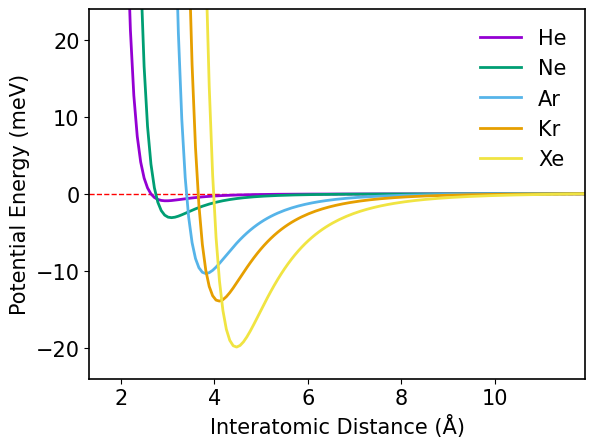

In [9]:
def VLJ(x, r0=1, eps=1, cutoff=3):
    rc = cutoff*r0
    V = lambda x: 4*eps*((r0/x)**12-(r0/x)**6)
    Vx = V(x)
    Vc = V(rc)
    return Vx - Vc

r0_min = min(SPECIES_DATA[sp]['r0'] for sp in SPECIES_DATA.keys())
r0_max = max(SPECIES_DATA[sp]['r0'] for sp in SPECIES_DATA.keys())
eps_max = max(SPECIES_DATA[sp]['eps'] for sp in SPECIES_DATA.keys())
x = np.linspace(r0_min/2, 4*r0_max, 200)


plt.rcParams.update({'font.size': 11, 'axes.linewidth': 1.2})
gnuplot_colors = [
    "#9400D3",  # 1: Dark Violet
    "#009E73",  # 2: Green
    "#56B4E9",  # 3: Light Blue
    "#E69F00",  # 4: Orange
    "#F0E442",  # 5: Yellow
    "#D55E00",  # 6: Hot Pink/Red
    "#CC79A7",  # 7: Cyan/Magenta
    "#555555"   # 8: Dark Gray
]
color_idx = 0
plt.axhline(0, color='red', linestyle='--', linewidth=1)

for sp in SPECIES_DATA.keys():
    if sp == '4He': continue # same as 3He
    r0 = SPECIES_DATA[sp]['r0']
    eps = SPECIES_DATA[sp]['eps']
    
    # Apply gnuplot line color, style, and thickness
    color = gnuplot_colors[color_idx % len(gnuplot_colors)]
    label = ('He' if sp=='3He' else sp)
    plt.plot(x, VLJ(x, r0, eps), label=label, color=color, linestyle='-', linewidth=2)
    color_idx += 1

plt.xlim(r0_min/2, 3*r0_max)
plt.ylim(-1.2*eps_max, 1.2*eps_max)
plt.xlabel('Interatomic Distance (Å)')
plt.ylabel('Potential Energy (meV)')
plt.legend(loc='upper right', frameon=True, facecolor='none', edgecolor='none')
plt.savefig('LJ-rare-gases.pdf', transparent=True)
plt.show()

# Classical

In [10]:
N_list = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
K_list = [1000, 2000, 4000, 8000, 16000]

In [11]:
T_min, T_max, num_T = 0.01, 0.6, 200
T_array = np.linspace(T_min, T_max, num_T)
beta_array = 1/(1*T_array) # kb=1 to compute themodynamic properties

force_recomputation = 0
for N, K in product(N_list, K_list):
    path_cls_N_K = os.path.join(path_cls, f'N{N}/K{K}')
    if os.path.exists(path_cls_N_K):
        # print(f'Found classical data for N={N}, K={K} at {path_cls_N_K}')
        file_name = 'computed_thermo_properties.txt'
        if not force_recomputation and os.path.exists(os.path.join(path_cls_N_K, file_name)):
            print(f'Using existing thermodynamic properties for N={N}, K={K} at {os.path.join(path_cls_N_K, file_name)}')
            continue
        os.chdir(path_cls_N_K)
        try:
            with open('nf_output_energy.txt', 'r') as f:
                logX, en = np.loadtxt(f, unpack=True)
                dos = np.exp(logX) # convert log(dos) to dos
        except FileNotFoundError:
            print(f'File not found for N={N}, K={K}')
            continue
        
        with open(file_name, 'w') as f:
            f.write('T\tlogZ\tU\tCv\n')
            T_array, logZ_array, U_array, Cv_array = compute_Z_c_nparray(dos, en, beta_array, N, dof=2, kb=1, kinetic_part=True)
            for T, logZ, U, Cv in zip(T_array, logZ_array, U_array, Cv_array):
                f.write(f'{T}\t{logZ}\t{U}\t{Cv}\n')
        print(f'Computed and saved thermodynamic properties for N={N}, K={K} at {path_cls_N_K}/computed_thermo_properties.txt')
    else:
        print(f'Skipping N={N}, K={K}... data not found at {path_cls_N_K}')

    

Using existing thermodynamic properties for N=2, K=1000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/classical/N2/K1000/computed_thermo_properties.txt
Using existing thermodynamic properties for N=2, K=2000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/classical/N2/K2000/computed_thermo_properties.txt
Using existing thermodynamic properties for N=2, K=4000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/classical/N2/K4000/computed_thermo_properties.txt
Using existing thermodynamic properties for N=2, K=8000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/classical/N2/K8000/computed_thermo_properties.txt
Using existing thermodynamic properties for N=2, K=16000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/classical/N2/K16000/computed_thermo_properties.txt
Using existing thermodynamic properties for N=3, K=1000 at /home/dph/nested_fit/tes

In [12]:
def plot_Cv_cls_grid(N_list, K_list, plot_U=False):
    if len(N_list) == 1:
        n_cols = 1
        n_rows = 1
    else:
        n_cols = 2
        n_rows = len(N_list) // n_cols + (len(N_list) % n_cols > 0)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*2, 5*n_rows), sharex=False, sharey=False)
    if len(N_list) == 1:
        axes = np.array([axes])  # Make it 2D for consistent indexing
    # if len(N_list) == 1 or len(K_list) == 1:
    #     axes = axes.reshape(-1, 1)
    
    # Generate colors based on the length of K_list
    colors = plt.cm.viridis_r(np.linspace(0, 1, len(K_list)))

    for i, N in enumerate(N_list):
        ax1 = plt.subplot(n_rows, n_cols, i+1)
        if plot_U:
            ax2 = ax1.twinx()
        for j, K in enumerate(K_list):
            path_cls_N_K = os.path.join(path_cls, f'N{N}/K{K}')
            if os.path.exists(path_cls_N_K):
                try:
                    data = np.loadtxt(os.path.join(path_cls_N_K, 'computed_thermo_properties.txt'), skiprows=1)
                    T_array, logZ_array, U_array, Cv_array = data.T
                    T_array, Cv_array, U_array = T_array*eps/kb, Cv_array*kb, U_array*eps
                    
                    # Passed color=colors[j] to the plots
                    ax1.plot(T_array, Cv_array, label=f'K={K}', color=colors[j])
                    if plot_U:
                        ax2.plot(T_array, U_array, label=f'U K={K}', linestyle='--', color=colors[j])
                except Exception as e:
                    print(f'Error loading data for N={N}, K={K}: {e}')
            else:
                print(f'No data found for N={N}, K={K} at {path_cls_N_K}')
        ax1.set_title(f'N={N}')
        ax1.set_xlabel(f'T ({T_units})')
        ax1.set_ylabel(f'Cv ({Cv_units})')
        if plot_U:
            ax2.set_ylabel(f'U ({U_units})')
        ax1.legend(loc='upper left')
    plt.tight_layout()
    plt.savefig(os.path.join(root_path, 'Cv_cls_grid_conv.png'))
    plt.savefig(os.path.join(root_path, 'Cv_cls_grid_conv.pdf'))
    plt.show()

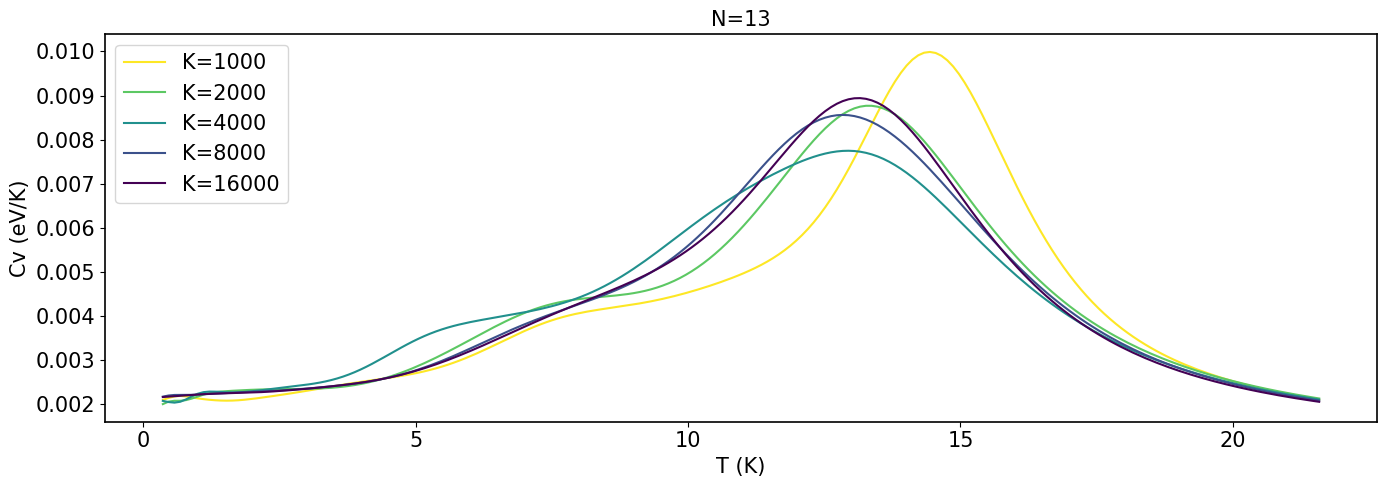

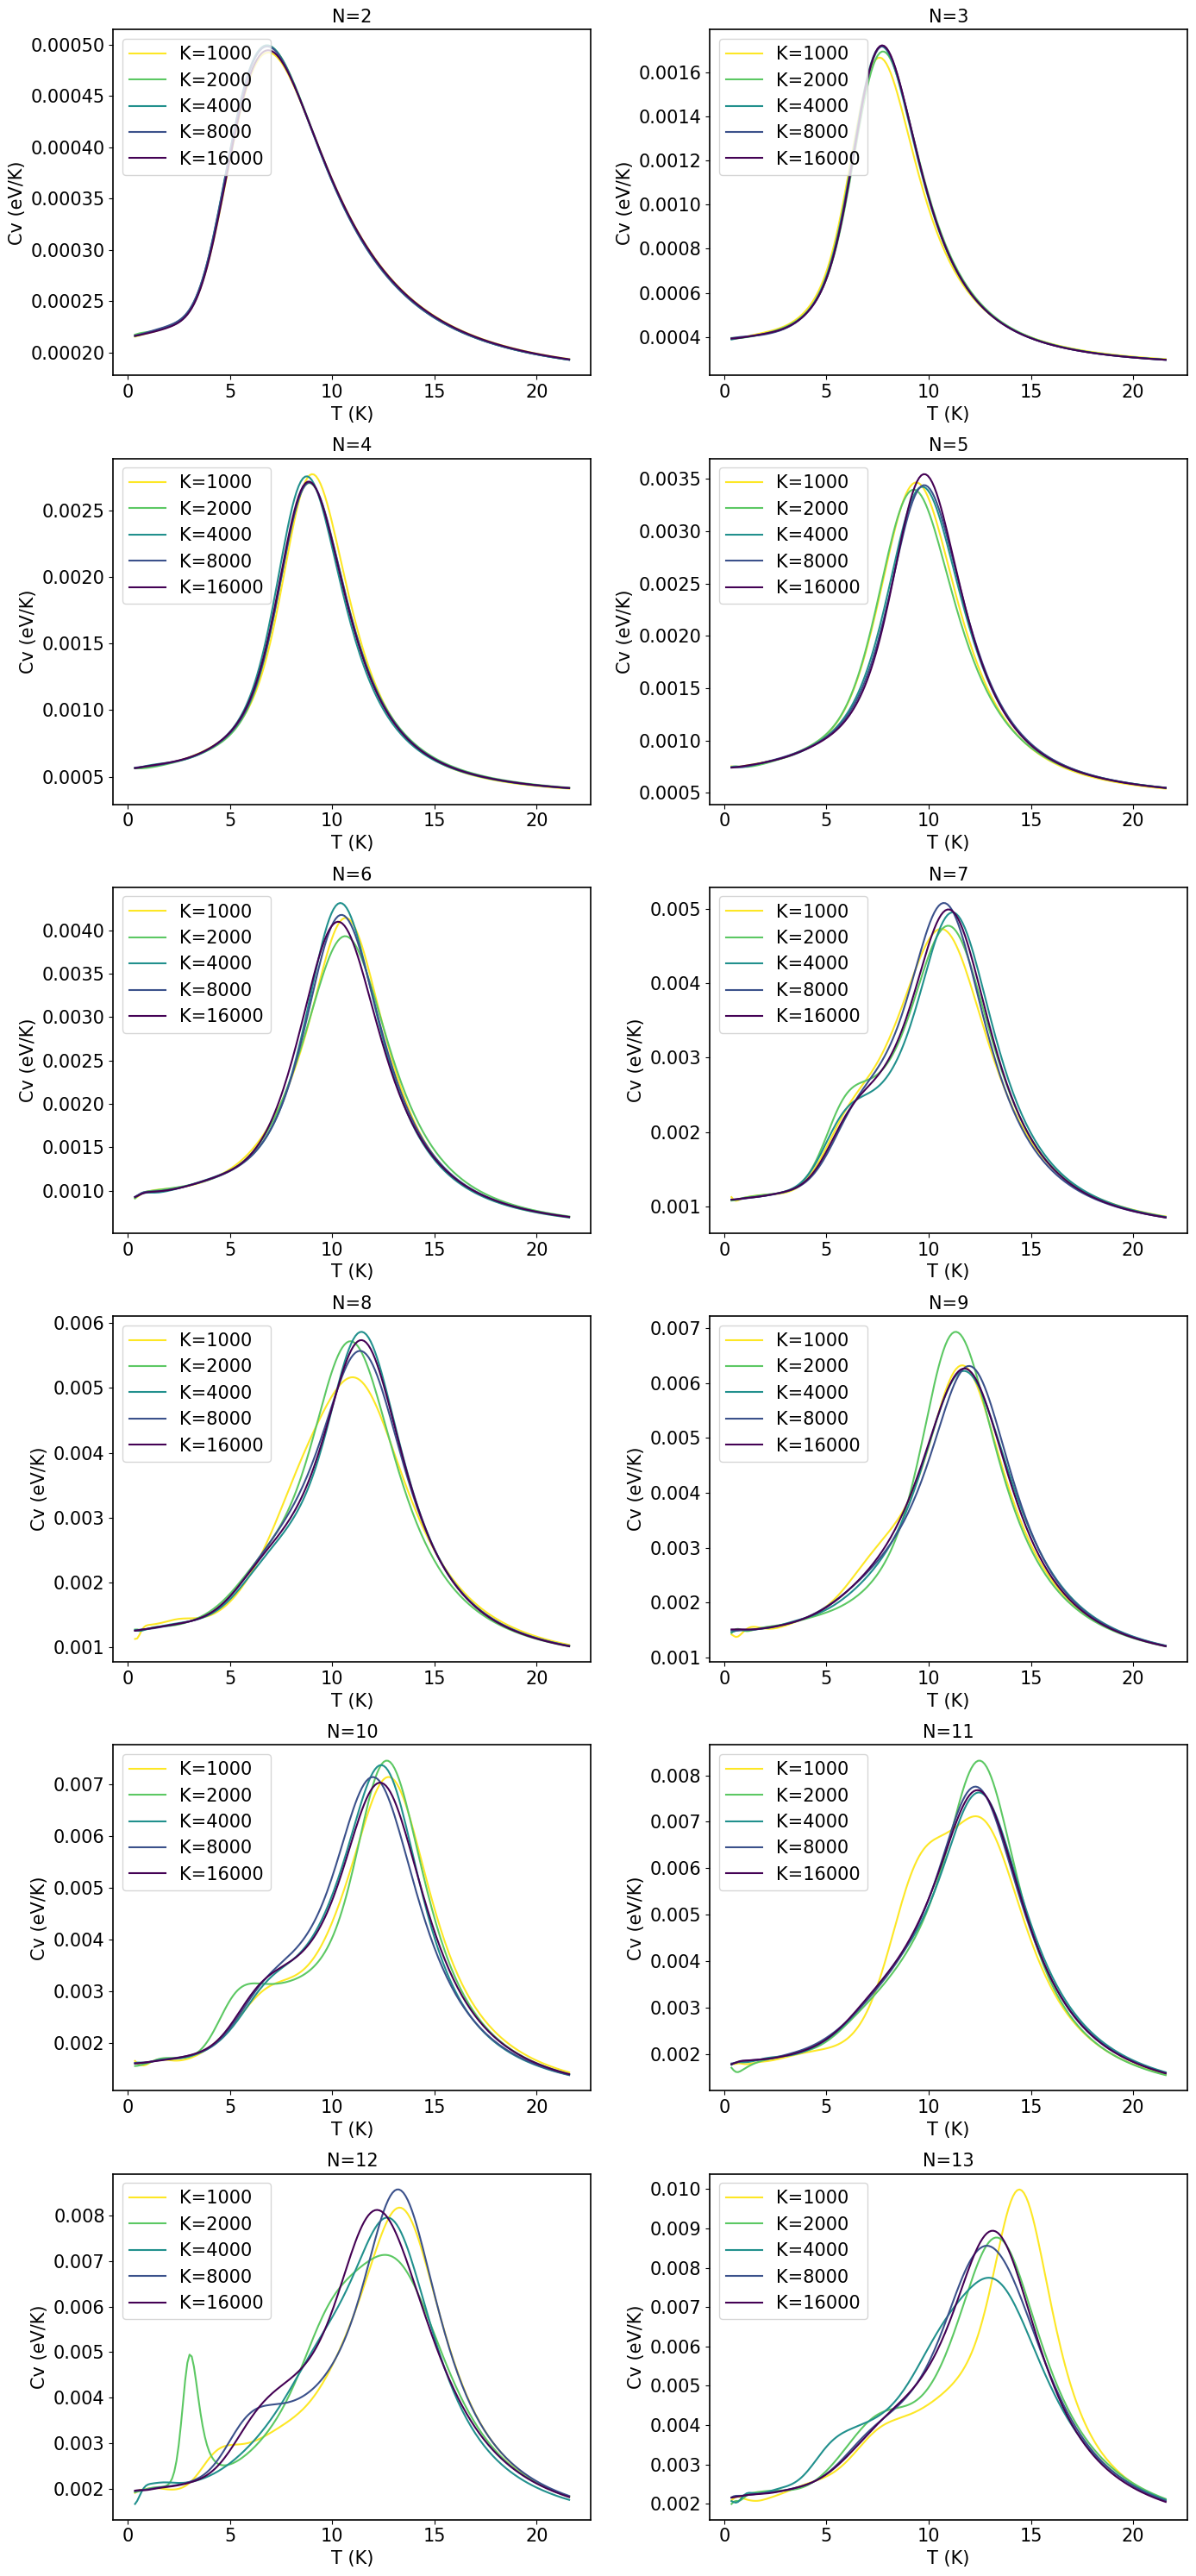

In [13]:
change_units('eV', species=CURRENT_SPECIES)
plot_Cv_cls_grid(N_list[-1:], K_list, plot_U=False)
plot_Cv_cls_grid(N_list, K_list, plot_U=False)

In [14]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

def plot_Cv_cls_grid_split_N(N_list, K_list, plot_U=False):
    # Set professional report typography styles
    plt.rcParams.update({'font.size': 11, 'axes.linewidth': 1.2})
    
    # Split N_list into first and second half
    mid = len(N_list) // 2
    cut = mid
    halves = [N_list[:cut], N_list[cut:]]
    
    # Create 1 row, 2 columns layout
    fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=False)
    
    target_K = K_list[-1]
    
    # Official modern gnuplot v5+ default color palette sequence hex definitions
    gnuplot_colors = [
        "#9400D3",  # 1: Dark Violet
        "#009E73",  # 2: Green
        "#56B4E9",  # 3: Light Blue
        "#E69F00",  # 4: Orange
        "#F0E442",  # 5: Yellow
        "#D55E00",  # 6: Hot Pink/Red
        "#CC79A7",  # 7: Cyan/Magenta
        "#555555"   # 8: Dark Gray
    ]
    
    for col_idx, n_sub_list in enumerate(halves):
        ax1 = axes[col_idx]
        # ax1.grid(True, linestyle=':', alpha=0.6, color='gray')
        
        ax2 = None
        if plot_U:
            ax2 = ax1.twinx()
            
        for i, N in enumerate(n_sub_list):
            path_cls_N_K = os.path.join(path_cls, f'N{N}/K{target_K}')
            if os.path.exists(path_cls_N_K):
                try:
                    data = np.loadtxt(os.path.join(path_cls_N_K, 'computed_thermo_properties.txt'), skiprows=1)
                    T_array, logZ_array, U_array, Cv_array = data.T
                    T_array, Cv_array, U_array = T_array*eps/kb, Cv_array*kb, U_array*eps
                    
                    # Track global indexing positions across all N entries to keep color maps sequential
                    global_idx = N_list.index(N)
                    color = gnuplot_colors[global_idx % len(gnuplot_colors)]
                    
                    # Core Cv curves
                    ax1.plot(T_array, Cv_array, color=color, linestyle='-', linewidth=2, label=f'N={N}')
                    
                    # Core U curves
                    if plot_U:
                        ax2.plot(T_array, U_array, color=color, linestyle='--', linewidth=1.5, alpha=0.7)
                        
                except Exception as e:
                    print(f'Error loading data for N={N}, K={target_K}: {e}')
            else:
                print(f'No data found for N={N}, K={target_K} at {path_cls_N_K}')
                
        # --- Axis Labels ---
        ax1.set_xlabel(f'Temperature ({T_units})', fontsize=11, labelpad=6)
        ax1.set_ylabel(f'Heat Capacity ({Cv_units})', fontsize=11, color='black')
        
        if plot_U:
            ax2.set_ylabel(f'Internal Energy ({U_units})', fontsize=11, color='darkred', rotation=270, labelpad=15)
            ax2.tick_params(axis='y', labelcolor='darkred')
            
            # Reconstruct stylized legend handles to capture the dual axis line formats
            handles, labels = ax1.get_legend_handles_labels()
            handles.append(Line2D([0], [0], color='gray', linestyle='-', linewidth=2))
            labels.append('$C_v$ (Solid)')
            handles.append(Line2D([0], [0], color='gray', linestyle='--', linewidth=1.5))
            labels.append('$U$ (Dashed)')
            ax1.legend(handles=handles, labels=labels, loc='upper left', frameon=True, facecolor='white', edgecolor='none')
        else:
            ax1.legend(loc='upper left', frameon=True, facecolor='white', edgecolor='none')
            
    plt.tight_layout()
    plt.savefig(os.path.join(root_path, 'Cv_cls_grid.png'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(root_path, 'Cv_cls_grid.pdf'), bbox_inches='tight')
    plt.show()

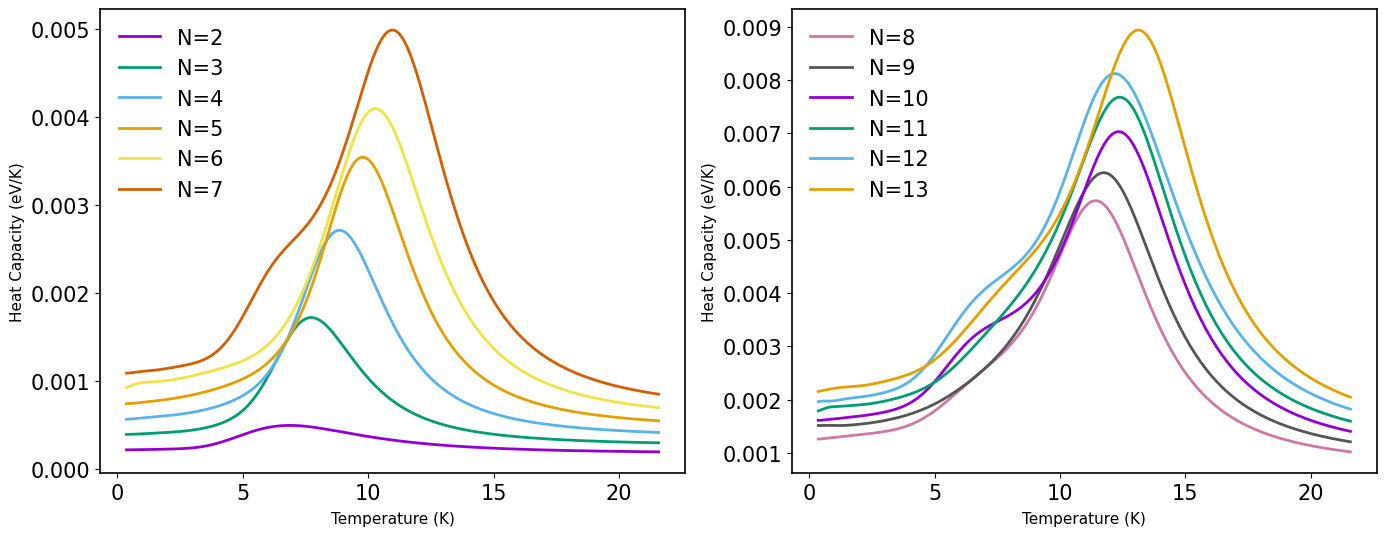

In [15]:
change_units('eV', species=CURRENT_SPECIES)
plot_Cv_cls_grid_split_N(N_list, K_list[-1:], plot_U=False)

In [16]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

def plot_points_cls_grid(N_list, K_list, plot_cluster=False):
    # Calculate dimensions for a clean 2-row layout configuration
    n_rows = 2
    n_cols = int(np.ceil(len(N_list) / n_rows))
    
    # Track the global absolute maximum coordinate to normalize scale sizes
    max_val = 0.0

    # --- GLOBAL BOUNDARY PRE-SCAN ---
    for N in N_list:
        for K in K_list:
            path_cls_N_K = os.path.join(path_cls, f'N{N}/K{K}')
            if os.path.exists(path_cls_N_K):
                try:
                    if plot_cluster:
                        filepath = os.path.join(path_cls_N_K, 'cluster_points_centered.txt')
                        # filepath = os.path.join(path_cls_N_K, 'cluster_points_aligned_pca.txt')
                        if os.path.exists(filepath):
                            with open(filepath, 'rb') as f:
                                try:
                                    f.seek(-2, os.SEEK_END)
                                    while f.read(1) != b'\n':
                                        f.seek(-2, os.SEEK_CUR)
                                except OSError:
                                    f.seek(0)
                                line_data = f.readline().decode().split()
                            coords = np.array(line_data[3:], dtype=float).reshape(N, 2)
                            max_val = max(max_val, np.max(np.abs(coords)))
                    else:
                        json_path = os.path.join(path_cls_N_K, 'nf_output_res.json')
                        if os.path.exists(json_path):
                            with open(json_path, 'r') as f:
                                js_data = json.load(f)
                            params = js_data['params']
                            coords = []
                            for k in range(1, N+1):
                                coords.append((params[f'x_{k}']['max'], params[f'y_{k}']['max']))
                            
                            images = [(x+dx, y+dy) for x, y in coords 
                                      for dx in range(-1, 2) for dy in range(-1, 2)]
                            max_val = max(max_val, np.max(np.abs(images)))
                except Exception:
                    pass

    if max_val == 0.0:
        max_val = 1.0 if not plot_cluster else 0.5
        
    max_val *= 2

    # Build the 2-row subplot environment
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), squeeze=False)
    
    # Force exact identical padding ratio both vertically (hspace) and horizontally (wspace)
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    
    axes_flat = axes.flatten()

    for i in range(n_rows * n_cols):
        ax1 = axes_flat[i]
        
        if i >= len(N_list):
            ax1.axis('off')
            continue
            
        N = N_list[i]
        ax1.set_aspect('equal')
        
        for j, K in enumerate(K_list):
            path_cls_N_K = os.path.join(path_cls, f'N{N}/K{K}')
            if os.path.exists(path_cls_N_K):
                try:
                    # --- PLOT CLUSTER FROM PROCESSED FILE ---
                    if plot_cluster:
                        filepath = os.path.join(path_cls_N_K, 'cluster_points_centered.txt')
                        # filepath = os.path.join(path_cls_N_K, 'cluster_points_aligned_pca.txt')
                        if os.path.exists(filepath):
                            with open(filepath, 'rb') as f:
                                try:
                                    f.seek(-2, os.SEEK_END)
                                    while f.read(1) != b'\n':
                                        f.seek(-2, os.SEEK_CUR)
                                except OSError:
                                    f.seek(0)
                                line_data = f.readline().decode().split()
                                
                                cluster_coords = np.array(line_data[3:], dtype=float).reshape(N, 2)
                                ax1.scatter(cluster_coords[:, 0], cluster_coords[:, 1], 
                                           marker='o', s=100, facecolors='r', 
                                           edgecolors='r', zorder=3)
                    # --- PLOT ORIGINAL IMAGES FROM JSON ---
                    else:
                        json_path = os.path.join(path_cls_N_K, 'nf_output_res.json')
                        with open(json_path, 'r') as f:
                            js_data = json.load(f)
                        
                        params = js_data['params']
                        coordinates = []
                        for k in range(1, N+1):
                            x_i = params[f'x_{k}']['max']
                            y_i = params[f'y_{k}']['max']
                            coordinates.append((x_i, y_i))
                        
                        images = [(x+dx, y+dy) for x, y in coordinates 
                                for dx in range(-1, 2) for dy in range(-1, 2) 
                                if not (dx == 0 and dy == 0)]
                        
                        ax1.scatter([x for x, y in coordinates], [y for x, y in coordinates], 
                                   label=f'K={K} Original', zorder=2)
                        ax1.scatter([x for x, y in images], [y for x, y in images], 
                                   marker='x', alpha=0.5, label=f'K={K} Images', zorder=1)

                except Exception as e:
                    print(f'Error loading data for N={N}, K={K}: {e}')
            else:
                print(f'No data found for N={N}, K={K} at {path_cls_N_K}')

        # --- UNIFORM LAYOUT ALIGNMENT & CLEANING ---
        ax1.set_xlim(-max_val, max_val)
        ax1.set_ylim(-max_val, max_val)
        
        # Strip ticks and labels cleanly
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax1.set_xticklabels([])
        ax1.set_yticklabels([])
        
        if not plot_cluster:
            ax1.vlines((0, 1), -max_val, max_val, colors='lightgray', linestyles='dashed', alpha=0.7)
            ax1.hlines((0, 1), -max_val, max_val, colors='lightgray', linestyles='dashed', alpha=0.7)
            ax1.legend(loc='upper left', fontsize='small')
            
        # --- EXACT LEGEND-POSITION LABELLING ---
        # AnchoredText calculates bounding box placements identically to legends.
        # We explicitly turn off the frame background to overlay clean, borderless text.
        anc_label = AnchoredText(f"N = {N}", loc='upper left', pad=0.3, borderpad=0.4,
                                 frameon=False, prop=dict(fontsize=20))
        ax1.add_artist(anc_label)
    
    # Save with tight bounding borders to avoid dynamic edge padding distortion
    plt.savefig(os.path.join(root_path, f"points_cls_grid{'_cluster' if plot_cluster else ''}.png"), 
                dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(root_path, f"points_cls_grid{'_cluster' if plot_cluster else ''}.pdf"), 
                bbox_inches='tight')
    plt.show()

### find and center clusters

In [17]:
import os
import subprocess
import numpy as np
import pandas as pd
from tqdm import tqdm


def process_clusters(
    root_path, N, K, b_min=0.0, b_max=1.0, n_seeds=1, chunk_size=10000
):
    L = b_max - b_min
    input_dir = os.path.join(root_path, f"N{N}/K{K}")
    input_path = os.path.join(input_dir, "nf_output_points.txt")

    # Guardrail 1: Check if path exists
    if not os.path.exists(input_path):
        print(f"File not found: {input_path}")
        return

    # Guardrail 2: Check if file is completely empty (0 bytes)
    if os.path.getsize(input_path) == 0:
        print(f"WARNING: File is empty (0 bytes): {input_path}. Skipping...")
        return

    unwrapped_file = os.path.join(input_dir, "cluster_points.txt")
    centered_file = os.path.join(input_dir, "cluster_points_centered.txt")

    # Clear existing output files if they exist so we can cleanly append
    if os.path.exists(unwrapped_file):
        os.remove(unwrapped_file)
    if os.path.exists(centered_file):
        os.remove(centered_file)

    n_seeds = min(n_seeds, N)

    # --- PROGRESS BAR SETUP ---
    print(
        f"Counting lines in original file for tracking (N={N}, K={K})..."
    )
    total_lines = int(
        subprocess.check_output(f"wc -l < {input_path}", shell=True)
    )
    total_chunks = int(np.ceil(total_lines / chunk_size))

    # Initialize the data iterator using modern pandas parsing mechanics
    data_iterator = pd.read_csv(
        input_path,
        sep=r"\s+",  # Handles irregular whitespace
        comment="#",  # Ignores commented lines
        header=None,  # No explicit headers
        skiprows=1,  # Skips the "# weight lnlikelihood parameters" line entirely
        skip_blank_lines=True,
        engine="python",  # Python engine cleanly ignores variable leading indentation
        chunksize=chunk_size,
    )

    print(f"\n>>> Starting streaming processing ({total_lines} total rows)")

    # Keep files open across chunks to reduce system file handle overhead
    with open(unwrapped_file, "a") as f_unwrapped, open(
        centered_file, "a"
    ) as f_centered, tqdm(
        total=total_chunks, ascii=True, desc="Processing Chunks", unit="chunk"
    ) as pbar:

        for chunk in data_iterator:
            data = chunk.to_numpy()

            meta = data[:, :3]  # weight, lnlikelihood, r0
            params = data[:, 3:]  # x1, y1, x2, y2...

            all_unwrapped = []
            all_centered = []

            # --- Your original processing loop ---
            for i in range(len(data)):
                coords = params[i].reshape(N, 2)
                best_rg = float("inf")
                best_unwrapped = None

                for s in range(n_seeds):
                    ref = coords[s]
                    diff = coords - ref
                    # Minimum Image Convention relative to anchor 's'
                    shifted_diff = diff - L * np.round(diff / L)
                    trial_unwrapped = ref + shifted_diff

                    # Calculate Radius of Gyration
                    com_trial = np.mean(trial_unwrapped, axis=0)
                    rg = np.sqrt(
                        np.mean(np.sum((trial_unwrapped - com_trial) ** 2, axis=1))
                    )

                    if rg < best_rg:
                        best_rg = rg
                        best_unwrapped = trial_unwrapped

                # Calculate final COM for the best configuration found
                final_com = np.mean(best_unwrapped, axis=0)
                centered = best_unwrapped - final_com

                all_unwrapped.append(best_unwrapped.flatten())
                all_centered.append(centered.flatten())

            # Convert chunk lists to arrays
            all_unwrapped = np.array(all_unwrapped)
            all_centered = np.array(all_centered)

            # Combine with chunk metadata
            out_unwrapped = np.hstack([meta, all_unwrapped])
            out_centered = np.hstack([meta, all_centered])

            # Write this chunk down to disk
            np.savetxt(f_unwrapped, out_unwrapped, fmt="%.18e")
            np.savetxt(f_centered, out_centered, fmt="%.18e")

            # Update progress bar
            pbar.update(1)

    print(f"\n<<< Finished N={N}, K={K}! Saved output locations:")
    print(f"  -> {unwrapped_file}")
    print(f"  -> {centered_file}")

In [18]:
# Execute
reprocess = 0 # /!\ may take a long time to process
if reprocess:
    for n in N_list:
        for k in K_list[-1:]:
            process_clusters(root_path=path_cls, N=n, K=k, b_min=0.0, b_max=1.0, n_seeds=2) # Replace with your actual N and K

### align clusters

In [19]:
import numpy as np
import os
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist

def align_series(root_path, N, K):
    input_dir = os.path.join(root_path, f'N{N}/K{K}')
    input_path = os.path.join(input_dir, 'cluster_points_centered.txt')
    
    if not os.path.exists(input_path):
        print(f"File not found: {input_path}")
        return

    # Load data: [weight, lnlikelihood, r0, x1, y1, x2, y2...]
    data = np.loadtxt(input_path)
    meta = data[:, :3]
    points_raw = data[:, 3:]
    
    num_sets = len(data)
    # Reshape to (number_of_sets, N_points, 2_dimensions)
    series = points_raw.reshape(num_sets, N, 2)
    
    # Storage for aligned points
    aligned_series = np.zeros_like(series)
    # The first element is our "anchor" reference
    aligned_series[0] = series[0]
    
    print(f"Aligning {num_sets} point sets for N={N}, K={K}...")

    for i in range(1, num_sets):
        target = aligned_series[i-1]  # Previous set (already aligned)
        source = series[i]            # Current set to align
        
        # 1. Solve the Correspondence Problem (Hungarian Algorithm)
        # Calculate cost matrix: distances between all possible pairs
        cost_matrix = cdist(target, source, metric='euclidean')
        row_ind, col_ind = linear_sum_assignment(cost_matrix)
        
        # Reorder source points to match target points
        source_ordered = source[col_ind]
        
        # 2. Solve the Rotation Problem (Kabsch Algorithm / SVD)
        # Both sets are already centered at (0,0) from your previous script
        H = target.T @ source_ordered
        U, S, Vt = np.linalg.svd(H)
        
        # Calculate rotation matrix
        R = U @ Vt
        
        # Handle reflection case (ensure it's a rotation, not a flip)
        if np.linalg.det(R) < 0:
            Vt[-1, :] *= -1
            R = U @ Vt
            
        # 3. Apply rotation to the original source (preserving its random order)
        # Or apply to ordered source if you want the labels to stay consistent
        aligned_series[i] = source @ R.T

    # Flatten back for saving
    aligned_flat = aligned_series.reshape(num_sets, -1)
    output_data = np.hstack([meta, aligned_flat])
    
    output_path = os.path.join(input_dir, 'cluster_points_aligned.txt')
    np.savetxt(output_path, output_data, fmt='%.18e')
    
    print(f"Alignment complete. Results saved to: {output_path}")

# Example Usage:
# root = "./data"
# align_series(root, N=13, K=100)

In [20]:
import os
import subprocess
import numpy as np
import pandas as pd
from scipy.optimize import linear_sum_assignment
from scipy.spatial.distance import cdist
from tqdm import tqdm


def get_pca_rotation(points):
    """Finds the rotation matrix to align points with their Principal Components."""
    cov = np.cov(points.T)
    eigenvalues, eigenvectors = np.linalg.eigh(cov)

    # Sort eigenvectors by eigenvalues descending (PC1, PC2)
    idx = eigenvalues.argsort()[::-1]
    eigenvectors = eigenvectors[:, idx]

    return eigenvectors


def align_series_with_pca(root_path, N, K, chunk_size=10000):
    input_dir = os.path.join(root_path, f"N{N}/K{K}")
    input_path = os.path.join(input_dir, "cluster_points_centered.txt")

    if not os.path.exists(input_path):
        print(f"File not found: {input_path}")
        return

    if os.path.getsize(input_path) == 0:
        print(f"WARNING: File is empty (0 bytes): {input_path}. Skipping...")
        return

    output_path = os.path.join(input_dir, "cluster_points_aligned_pca.txt")

    # Clear old file if it exists so we append cleanly
    if os.path.exists(output_path):
        os.remove(output_path)

    # --- PROGRESS BAR SETUP ---
    print(
        f"Counting lines in centered file for tracking (N={N}, K={K})..."
    )
    total_lines = int(
        subprocess.check_output(f"wc -l < {input_path}", shell=True)
    )
    total_chunks = int(np.ceil(total_lines / chunk_size))

    # Initialize streaming chunk iterator
    data_iterator = pd.read_csv(
        input_path,
        sep=r"\s+",
        comment="#",
        header=None,
        skip_blank_lines=True,
        engine="python",
        chunksize=chunk_size,
    )

    print(f"\n>>> Starting PCA alignment streaming ({total_lines} total rows)")

    # Track target reference across chunks
    target = None

    # Keep output file open across chunks to avoid OS resource overhead
    with open(output_path, "a") as f_out, tqdm(
        total=total_chunks,
        desc="Aligning Chunks",
        unit="chunk",
        ascii=True,  # Restricts progress bar visual components to standard ASCII characters
    ) as pbar:

        for chunk in data_iterator:
            data = chunk.to_numpy()
            meta = data[:, :3]
            points_raw = data[:, 3:]
            num_sets = len(data)

            series = points_raw.reshape(num_sets, N, 2)
            aligned_series = np.zeros_like(series)

            # --- Handle first element condition across chunks ---
            start_idx = 0
            if target is None:
                # If this is absolute frame 0 of the entire file
                aligned_series[0] = series[0]
                target = aligned_series[0]
                start_idx = 1

            for i in range(start_idx, num_sets):
                source = series[i]

                # --- STEP 1: PCA Coarse Alignment ---
                target_axes = get_pca_rotation(target)
                source_axes = get_pca_rotation(source)

                # Rotation to align source axes to target axes
                R_pca = target_axes @ source_axes.T
                source_pca = source @ R_pca.T

                # PCA Ambiguity: Test 180-degree flip
                R_flip = np.array([[-1, 0], [0, -1]])
                source_pca_flipped = source_pca @ R_flip.T

                dist1 = np.sum(np.min(cdist(target, source_pca), axis=1))
                dist2 = np.sum(np.min(cdist(target, source_pca_flipped), axis=1))

                if dist2 < dist1:
                    source_candidate = source_pca_flipped
                    R_initial = R_flip @ R_pca
                else:
                    source_candidate = source_pca
                    R_initial = R_pca

                # --- STEP 2: Fine-Tuning (Hungarian + SVD) ---
                cost_matrix = cdist(
                    target, source_candidate, metric="euclidean"
                )
                _, col_ind = linear_sum_assignment(cost_matrix)
                source_ordered = source_candidate[col_ind]

                # Final SVD refinement
                H = target.T @ source_ordered
                U, S, Vt = np.linalg.svd(H)
                R_fine = U @ Vt

                # Combined Rotation matrix
                R_final = R_fine @ R_initial

                # Apply to original source and cache as next target
                aligned_series[i] = source @ R_final.T
                target = aligned_series[i]

            # Flatten and prepare current processed chunk matrix
            aligned_flat = aligned_series.reshape(num_sets, -1)
            output_chunk_data = np.hstack([meta, aligned_flat])

            # Write chunk down to disk and increment tracker
            np.savetxt(f_out, output_chunk_data, fmt="%.18e")
            pbar.update(1)

    print(f"\n<<< Finished N={N}, K={K}! Saved output location:")
    print(f"  -> {output_path}")

In [21]:
import numpy as np
import os

def align_series_pca_only(root_path, N, K):
    input_dir = os.path.join(root_path, f'N{N}/K{K}')
    input_path = os.path.join(input_dir, 'cluster_points_centered.txt')
    
    if not os.path.exists(input_path):
        print(f"File not found: {input_path}")
        return

    # Load: [meta0, meta1, meta2, x1, y1, ...]
    data = np.loadtxt(input_path)
    meta = data[:, :3]
    series = data[:, 3:].reshape(-1, N, 2)
    
    aligned_series = np.zeros_like(series)
    
    for i in range(len(series)):
        current = series[i] # Already centered at (0,0)
        
        # 1. Get Principal Components via Covariance Matrix
        # Covariance = (1/n) * X^T * X
        cov = np.dot(current.T, current) / (N - 1)
        vals, vecs = np.linalg.eigh(cov)
        
        # Sort eigenvectors so the one with the largest eigenvalue is first
        idx = np.argsort(vals)[::-1]
        R = vecs[:, idx] 
        
        # 2. Rotate current set to the "Standard" PCA frame
        # This aligns the long axis to X and short axis to Y
        candidate = np.dot(current, R)
        
        # 3. Handle the 180-degree flip ambiguity
        if i > 0:
            # Compare candidate to previous aligned set
            # Since labels are random, we compare the "global spread" 
            # or just a simple distance check
            prev = aligned_series[i-1]
            
            # Check if flipping X or Y axes makes it closer to the previous frame
            # We test the 4 possible symmetry flips of PCA axes
            flips = [
                np.array([1, 1]),   # No flip
                np.array([-1, 1]),  # Flip X
                np.array([1, -1]),  # Flip Y
                np.array([-1, -1])  # Flip both
            ]
            
            best_dist = float('inf')
            best_config = candidate
            
            for f in flips:
                trial = candidate * f
                # Use a simple sum of distances to the nearest neighbor 
                # (Heuristic since labels are random)
                # For small N, this is very fast
                dists = np.sum(np.min(np.linalg.norm(trial[:, None] - prev[None, :], axis=2), axis=1))
                if dists < best_dist:
                    best_dist = dists
                    best_config = trial
            
            aligned_series[i] = best_config
        else:
            aligned_series[0] = candidate

    # Flatten and Save
    out_flat = aligned_series.reshape(len(data), -1)
    output_data = np.hstack([meta, out_flat])
    out_path = os.path.join(input_dir, 'cluster_points_pca_only.txt')
    np.savetxt(out_path, output_data, fmt='%.18e')
    print(f"PCA alignment saved to: {out_path}")

# Example usage:
# align_series_pca_only(root_path, N, K)

In [22]:
# Execute
reprocess = 0 # /!\ may take a long time to process
if reprocess:
    for n in N_list:
        for k in K_list[-1:]:
            align_series_with_pca(root_path=path_cls, N=n, K=k)
            # align_series_pca_only(root_path=path_cls, N=n, K=k)


### plot clusters

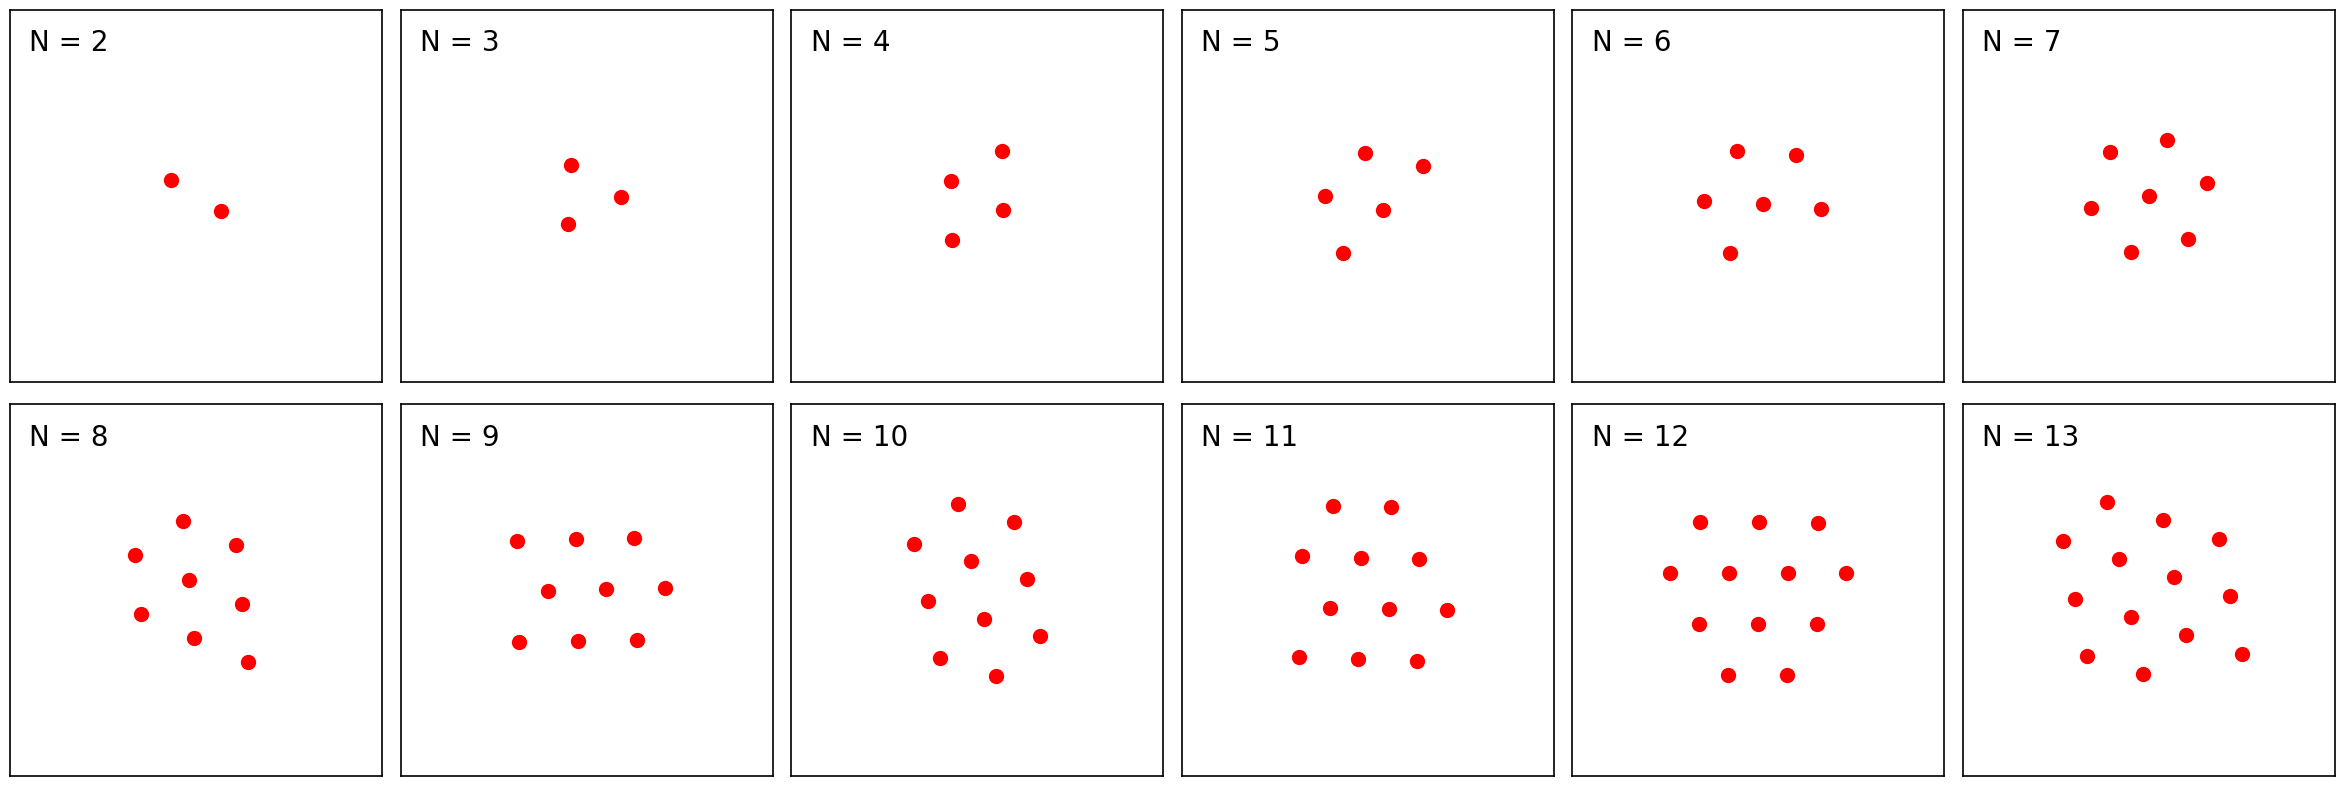

In [23]:
# plot_points_cls_grid(N_list, K_list=[K_list[-1]])
plot_points_cls_grid(N_list, K_list[-1:], plot_cluster=True)

# N=6 configurations

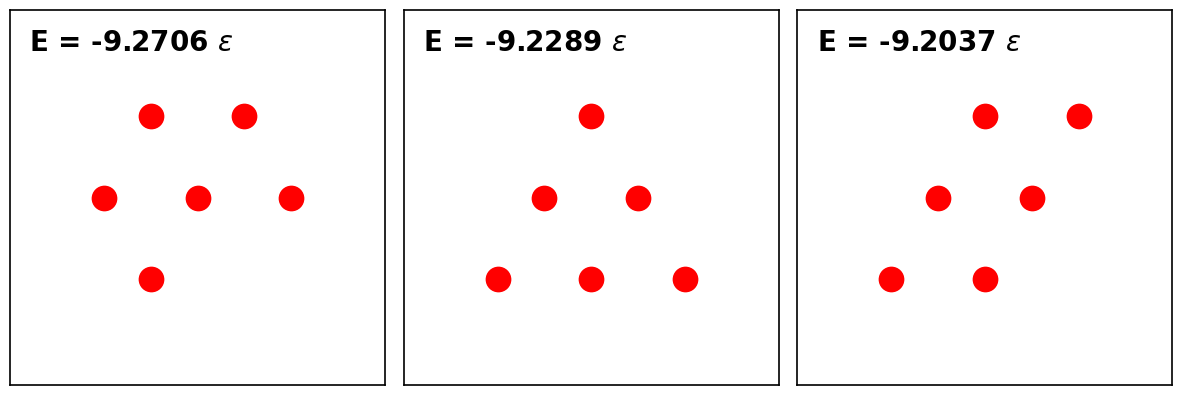

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import AnchoredText

def VLJ(x, r0=1, eps=1, cutoff=3):
    rc = cutoff*r0
    V = lambda x: 4*eps*((r0/x)**12-(r0/x)**6)
    Vx = V(x)
    Vc = V(rc)
    return Vx - Vc

def plot_perfect_grid_n6():
    # Locked analytic nearest neighbor distance for an isolated pair minimum
    d = 0.5
    
    # Define exact perfect grid coordinates for the 3 configurations
    # Configurations are centered near (0,0)
    configs_coords = {
        "Hexagon": np.array([
            [0, 0],
            [d, 0],
            [d/2, np.sqrt(3)*d/2],
            [-d/2, np.sqrt(3)*d/2],
            [-d, 0],
            [-d/2, -np.sqrt(3)*d/2]
        ]),
        "Triangle": np.array([
            [-d, -np.sqrt(3)*d/2], [0, -np.sqrt(3)*d/2], [d, -np.sqrt(3)*d/2],
            [-d/2, 0], [d/2, 0],
            [0, np.sqrt(3)*d/2]
        ]),
        "Rhomboid": np.array([
            [-d, -np.sqrt(3)*d/2], [0, -np.sqrt(3)*d/2],
            [-d/2, 0], [d/2, 0],
            [0, np.sqrt(3)*d/2], [d, np.sqrt(3)*d/2]
        ])
    }
    
    config_names = list(configs_coords.keys())
    
    # Structural layout specifications matching template dimensions
    n_rows = 1
    n_cols = 3  # Generates 4 cells total to hold our 3 configurations
    
    # Establish bounding box scaling using max coordinates
    max_val = 0.0
    for coords in configs_coords.values():
        # Center coordinates per cluster to match 'cluster_points_centered.txt' style
        centered = coords - np.mean(coords, axis=0)
        max_val = max(max_val, np.max(np.abs(centered)))
        
    max_val *= 1.8  # Clean margin buffer padding

    max_val = 1

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(5 * n_cols, 5 * n_rows), squeeze=False,
                             facecolor='none')
    plt.subplots_adjust(wspace=0.05, hspace=0.05)
    axes_flat = axes.flatten()

    for i in range(n_rows * n_cols):
        ax1 = axes_flat[i]
        
        # Turn off excess subplot frames if out of data boundaries
        if i >= len(config_names):
            ax1.axis('off')
            continue
            
        name = config_names[i]
        raw_coords = configs_coords[name]
        cluster_coords = raw_coords #- np.mean(raw_coords, axis=0)  # Zero-center tracking
        
        # --- CALCULATE TOTAL SYSTEM ENERGY ---
        energy = 0.0
        n_atoms = len(cluster_coords)
        for m in range(n_atoms):
            for k in range(m + 1, n_atoms):
                r = np.linalg.norm(cluster_coords[m] - cluster_coords[k])
                energy += VLJ(r, r0=0.5/(2**(1/6)), eps=1)
                
        ax1.set_aspect('equal')
        
        # # --- DRAW STRUCTURAL BONDS (1st Shell: r ≈ d) ---
        # for m in range(6):
        #     for n in range(m + 1, 6):
        #         r = np.linalg.norm(cluster_coords[m] - cluster_coords[n])
        #         if 0.95 * d <= r <= 1.05 * d:
        #             ax1.plot([cluster_coords[m, 0], cluster_coords[n, 0]], 
        #                      [cluster_coords[m, 1], cluster_coords[n, 1]], 
        #                      color='crimson', linewidth=2.5, zorder=2)
        
        # --- PLOT CLUSTER POINTS ---
        ax1.scatter(cluster_coords[:, 0], cluster_coords[:, 1], 
                    marker='o', s=300, facecolors='r', 
                    linewidths=1.2, zorder=3)
        ax1.set_facecolor('white')
        
        # --- UNIFORM LAYOUT ALIGNMENT & CLEANING ---
        ax1.set_xlim(-max_val, max_val)
        ax1.set_ylim(-max_val, max_val)
        
        # Strip all ticks and background frames cleanly
        ax1.set_xticks([])
        ax1.set_yticks([])
        ax1.set_xticklabels([])
        ax1.set_yticklabels([])
        
        # --- EXACT LEGEND-POSITION LABELLING ---
        # Frameless anchored text layout parameter overlays matching template
        anc_label = AnchoredText(rf"E = {energy:.4f} $\epsilon$", loc='upper left', pad=0.3, borderpad=0.4,
                                 frameon=False, prop=dict(fontsize=20, weight='bold'))
        ax1.add_artist(anc_label)
    
    plt.savefig("points_cls_grid_perfect_n6.png", dpi=300, bbox_inches='tight')
    plt.savefig("points_cls_grid_perfect_n6.pdf", bbox_inches='tight', transparent=False)
    plt.show()

if __name__ == "__main__":
    plot_perfect_grid_n6()

# Quantum N=6

## Direct

In [25]:
N = 6
P_list = [2, 4, 8] # 16
K_list = [1000, 2000, 4000]

CURRENT_SPECIES = '3He' # 3He, Ne, Ar, Kr

tau_min, tau_max = 0.01, 0.6
# tau_list = np.linspace(tau_min, tau_max, 10)
tau_list = np.linspace(tau_min, tau_max, 19)[:10] # explore half the range
tau_list = np.concatenate((tau_list, np.linspace(tau_min, tau_max, 10)[5:]))
beta_list = 1/(1*tau_list) # kb=1 to compute thermodynamic properties
print(f'tau_list: {tau_list}')

tau_list: [0.01       0.04277778 0.07555556 0.10833333 0.14111111 0.17388889
 0.20666667 0.23944444 0.27222222 0.305      0.33777778 0.40333333
 0.46888889 0.53444444 0.6       ]


In [26]:
# direct method
recalculate_taus = 0 # Set to True to force recalculation of thermodynamic properties, even if the output file already exists
for P in P_list:
    for K in K_list:
        path_dir_N_P_K = os.path.join(path_dir, f'{CURRENT_SPECIES}/N{N}/P{P}/K{K}')
        if not os.path.exists(path_dir_N_P_K):
            print(f'Skipping N={N}, P={P}, K={K}... data not found at {path_dir_N_P_K}')
            continue
        if not recalculate_taus and os.path.exists(os.path.join(path_dir_N_P_K, 'computed_thermo_properties.txt')):
            print(f'Using existing thermodynamic properties for N={N}, P={P}, K={K} at {path_dir_N_P_K}/computed_thermo_properties.txt')
            continue
        with open(os.path.join(path_dir_N_P_K, 'computed_thermo_properties.txt'), 'w') as f_out:
            f_out.write('T\tlogZ\tU\tCv\n')
            print(f'Computing for for N={N}, P={P}, K={K}...')
            for tau in tau_list:
                path_dir_N_P_K_tau = os.path.join(path_dir_N_P_K, f'tau{tau:.3f}')
                if os.path.exists(path_dir_N_P_K_tau):
                    try:
                        with open(os.path.join(path_dir_N_P_K_tau, 'nf_output_energy.txt'), 'r') as f:
                            logX, E, V, Q, T = np.loadtxt(f, unpack=True)
                            dos = np.exp(logX) # convert log(dos) to dos
                            en = np.array([E, V, Q, T]) # energy components for compute_Z_q_dir
                    except FileNotFoundError:
                        print(f'File not found for N={N}, P={P}, K={K}, tau={tau:.3f}')
                        continue
                    T, logZ, U, Cv = compute_Z_q_dir(dos, en, N, P, dof=2, kb=1, kinetic_part=True)
                    f_out.write(f'{T}\t{logZ}\t{U}\t{Cv}\n')
                else:
                    print(f'Skipping N={N}, P={P}, K={K}, tau={tau:.3f}... data not found at {path_dir_N_P_K_tau}')
            print(f'Computed and saved thermodynamic properties for N={N}, P={P}, K={K} at {path_dir_N_P_K}/computed_thermo_properties.txt')

Using existing thermodynamic properties for N=6, P=2, K=1000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/q_direct/3He/N6/P2/K1000/computed_thermo_properties.txt
Using existing thermodynamic properties for N=6, P=2, K=2000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/q_direct/3He/N6/P2/K2000/computed_thermo_properties.txt
Skipping N=6, P=2, K=4000... data not found at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/q_direct/3He/N6/P2/K4000
Using existing thermodynamic properties for N=6, P=4, K=1000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/q_direct/3He/N6/P4/K1000/computed_thermo_properties.txt
Using existing thermodynamic properties for N=6, P=4, K=2000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/q_direct/3He/N6/P4/K2000/computed_thermo_properties.txt
Skipping N=6, P=4, K=4000... data not found at /home/dph/nested_fit/test_LJ/cl

In [27]:
def plot_Cv_dir_grid(path_dir, N_list, P_list, K_list, plot_classical=False, path_cls=None, plot_U=False):
    if len(N_list) == 1:
        n_cols = 1
        n_rows = 1
    else:
        n_cols = 2
        n_rows = len(N_list) // n_cols + (len(N_list) % n_cols > 0)
        
    # Gnuplot v5+ default color palette sequence definitions
    gnuplot_colors = [
        "#9400D3",  # 1: Dark Violet
        "#009E73",  # 2: Green
        "#56B4E9",  # 3: Light Blue
        "#E69F00",  # 4: Orange
        "#F0E442",  # 5: Yellow
        "#D55E00",  # 6: Hot Pink/Red
        "#CC79A7",  # 7: Cyan/Magenta
        "#555555"   # 8: Dark Gray
    ]
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 5*n_rows), sharex=False, sharey=False)
    if len(N_list) == 1:
        axes = np.array([axes])  # Make it 2D for consistent indexing
        
    for i, N in enumerate(N_list):
        ax1 = plt.subplot(n_rows, n_cols, i+1)
        if plot_U:
            ax2 = ax1.twinx()
            
        if plot_classical:
            # Extract all K values from folder names (e.g., 'K1000', 'K2000' -> [1000, 2000])
            K_values = [int(d[1:]) for d in os.listdir(os.path.join(path_cls, f'N{N}')) if d.startswith('K') and d[1:].isdigit()]
            K_max = max(K_values)
            K_cls = K_max  # use maximum K for classical comparison
            path_cls_N_K = os.path.join(path_cls, f'N{N}/K{K_cls}')
            if os.path.exists(path_cls_N_K):
                try:
                    data_cls = np.loadtxt(os.path.join(path_cls_N_K, 'computed_thermo_properties.txt'), skiprows=1)
                    T_array_cls, logZ_array_cls, U_array_cls, Cv_array_cls = data_cls.T
                    T_array_cls, Cv_array_cls, U_array_cls = T_array_cls*eps/kb, Cv_array_cls*kb, U_array_cls*eps
                    # ax1.plot(T_array_cls, Cv_array_cls, '-', color='black', label=f'Classical Cv (K={K_cls})')
                    ax1.plot(T_array_cls, Cv_array_cls, '-', color='black', label=f'Classical')
                    if plot_U:
                        ax2.plot(T_array_cls, U_array_cls, '--', color='black', label=f'Classical U (K={K_cls})')
                except Exception as e:
                    print(f'Error loading classical data for N={N}, K={K_cls}: {e}')
            else:
                print(f'No classical data found for N={N}, K={K_cls} at {path_cls_N_K}')
                
        # Counter to sequentially index the gnuplot colors array within each subplot frame
        color_idx = 0
        
        for P in P_list:
            for K in K_list:
                path_dir_N_P_K = os.path.join(path_dir, f'{CURRENT_SPECIES}/N{N}/P{P}/K{K}')
                if os.path.exists(path_dir_N_P_K):
                    try:
                        data = np.loadtxt(os.path.join(path_dir_N_P_K, 'computed_thermo_properties.txt'), skiprows=1)
                        T_array, logZ_array, U_array, Cv_array = data.T
                        T_array, Cv_array, U_array = T_array*eps/kb, Cv_array*kb, U_array*eps
                        
                        # Grab current sequential color map entry
                        current_color = gnuplot_colors[color_idx % len(gnuplot_colors)]
                        
                        # ax1.plot(T_array, Cv_array, 'o-', markersize=4, color=current_color, label=f'P={P}, K={K}')
                        ax1.plot(T_array, Cv_array, 'o-', markersize=4, color=current_color, label=f'P={P}')
                        if plot_U:
                            ax2.plot(T_array, U_array, 'd--', markersize=4, color=current_color, label=f'U P={P}, K={K}')
                        
                        color_idx += 1  # Increment only after a line has successfully been plotted
                    except Exception as e:
                        print(f'Error loading data for N={N}, P={P}, K={K}: {e}')
                else:
                    print(f'No data found for N={N}, P={P}, K={K} at {path_dir_N_P_K}')
                    
        ax1.set_title(rf'{CURRENT_SPECIES} ($\Lambda$={SPECIES_DATA[CURRENT_SPECIES]["Lambda"]})', fontsize=20)# N={N}')
        ax1.set_xlabel(f'T ({T_units})')
        ax1.set_ylabel(f'Cv ({Cv_units})')
        if plot_U:
            ax2.set_ylabel(f'U ({U_units})')
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1, loc='center right', fontsize=10)
        else:
            ax1.legend(loc='best')
            
    plt.tight_layout()
    plt.savefig(os.path.join(root_path, f'Cv_dir_{CURRENT_SPECIES}_grid.png'))
    plt.savefig(os.path.join(root_path, f'Cv_dir_{CURRENT_SPECIES}_grid.pdf'))
    plt.show()

No data found for N=6, P=2, K=4000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/q_direct/3He/N6/P2/K4000
No data found for N=6, P=4, K=4000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/q_direct/3He/N6/P4/K4000
No data found for N=6, P=8, K=4000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/q_direct/3He/N6/P8/K4000


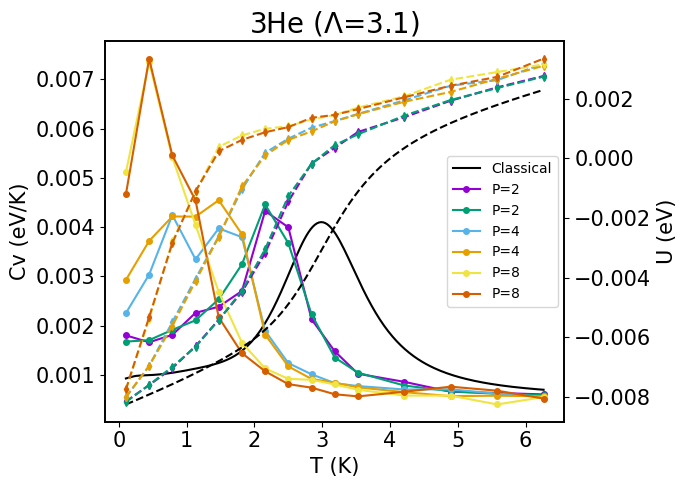

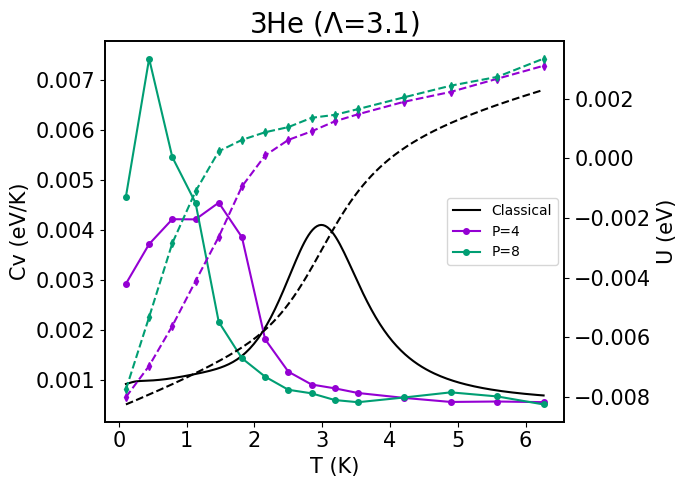

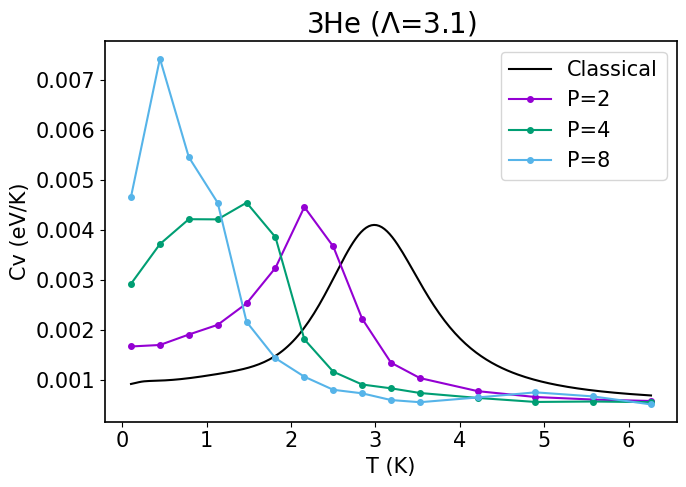

In [28]:
change_units('eV', species=CURRENT_SPECIES)
plot_Cv_dir_grid(path_dir, [N], P_list, K_list, plot_classical=True, path_cls=path_cls, plot_U=True)
plot_Cv_dir_grid(path_dir, [N], [4, 8], [2000], plot_classical=True, path_cls=path_cls, plot_U=True)
plot_Cv_dir_grid(path_dir, [N], P_list, [2000], plot_classical=True, path_cls=path_cls, plot_U=False)

In [29]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_Cv_dir_grid(path_dir, SPECIES_list, N, P_list, K_list, plot_classical=False, path_cls=None, plot_U=False):
    # Calculate grid layout dimensions driven entirely by the SPECIES_list length
    if len(SPECIES_list) == 1:
        n_cols = 1
        n_rows = 1
    else:
        n_cols = 2
        n_rows = len(SPECIES_list) // n_cols + (len(SPECIES_list) % n_cols > 0)
        
    gnuplot_colors = [
        "#9400D3",  # 1: Dark Violet
        "#009E73",  # 2: Green
        "#56B4E9",  # 3: Light Blue
        "#E69F00",  # 4: Orange
        "#F0E442",  # 5: Yellow
        "#D55E00",  # 6: Hot Pink/Red
        "#CC79A7",  # 7: Cyan/Magenta
        "#555555"   # 8: Dark Gray
    ]
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(7*n_cols, 5*n_rows), sharex=False, sharey=False)
    if len(SPECIES_list) == 1:
        axes = np.array([axes])  # Keep 2D consistency
        
    for i, species in enumerate(SPECIES_list):
        ax1 = plt.subplot(n_rows, n_cols, i+1)
        if plot_U:
            ax2 = ax1.twinx()
            
        if plot_classical:
            path_species_cls = os.path.join(path_cls, f'N{N}')
            if os.path.exists(path_species_cls):
                # Dynamically isolate maximum K from folders inside target cluster directory
                K_values = [int(d[1:]) for d in os.listdir(path_species_cls) if d.startswith('K') and d[1:].isdigit()]
                if K_values:
                    K_cls = max(K_values)
                    path_cls_N_K = os.path.join(path_species_cls, f'K{K_cls}')
                    if os.path.exists(path_cls_N_K):
                        try:
                            data_cls = np.loadtxt(os.path.join(path_cls_N_K, 'computed_thermo_properties.txt'), skiprows=1)
                            T_array_cls, logZ_array_cls, U_array_cls, Cv_array_cls = data_cls.T
                            T_array_cls, Cv_array_cls, U_array_cls = T_array_cls*eps/kb, Cv_array_cls*kb, U_array_cls*eps
                            # ax1.plot(T_array_cls, Cv_array_cls, '-', color='black', label=f'Classical Cv (K={K_cls})')
                            ax1.plot(T_array_cls, Cv_array_cls, '-', color='black', label=f'Classical')
                            if plot_U:
                                ax2.plot(T_array_cls, U_array_cls, '--', color='black', label=f'Classical U (K={K_cls})')
                        except Exception as e:
                            print(f'Error loading classical data for species {species}, N={N}, K={K_cls}: {e}')
                else:
                    print(f'No classical K subdirectories found at {path_species_cls}')
            else:
                print(f'Classical directory path not found: {path_species_cls}')
                
        # Handle sequential color selections per subplot frame
        color_idx = 0
        
        for P in P_list:
            for K in K_list:
                # CHANGED: Replaced global CURRENT_SPECIES state check with loop-injected species iteration variable
                path_dir_N_P_K = os.path.join(path_dir, f'{species}/N{N}/P{P}/K{K}')
                if os.path.exists(path_dir_N_P_K):
                    try:
                        data = np.loadtxt(os.path.join(path_dir_N_P_K, 'computed_thermo_properties.txt'), skiprows=1)
                        T_array, logZ_array, U_array, Cv_array = data.T
                        T_array, Cv_array, U_array = T_array*eps/kb, Cv_array*kb, U_array*eps
                        
                        current_color = gnuplot_colors[color_idx % len(gnuplot_colors)]
                        
                        # ax1.plot(T_array, Cv_array, 'o-', markersize=4, color=current_color, label=f'P={P}, K={K}')
                        ax1.plot(T_array, Cv_array, 'o-', markersize=4, color=current_color, label=f'P={P}')
                        if plot_U:
                            ax2.plot(T_array, U_array, 'd--', markersize=4, color=current_color, label=f'U P={P}, K={K}')
                        
                        color_idx += 1
                    except Exception as e:
                        print(f'Error loading data for species {species}, N={N}, P={P}, K={K}: {e}')
                else:
                    print(f'No data found for species {species}, N={N}, P={P}, K={K} at {path_dir_N_P_K}')
                    
        # CHANGED: Title and dictionary metrics now update based on active loop species element
        ax1.set_title(rf'{species} ($\Lambda$={SPECIES_DATA[species]["Lambda"]})', 
                      fontsize=20)
        ax1.set_xlabel(f'Temperature ({T_units})')
        ax1.set_ylabel(f'Heat capacity ({Cv_units})')
        if plot_U:
            ax2.set_ylabel(f'U ({U_units})')
            lines1, labels1 = ax1.get_legend_handles_labels()
            lines2, labels2 = ax2.get_legend_handles_labels()
            ax1.legend(lines1 + lines2, labels1, loc='center right', fontsize=8)
        else:
            ax1.legend(loc='best')
            
    plt.tight_layout()
    # CHANGED: File outputs match the target non-species-specific names requested
    plt.savefig(os.path.join(root_path, 'Cv_dir_grid.png'))
    plt.savefig(os.path.join(root_path, 'Cv_dir_grid.pdf'))
    plt.show()

No data found for species 3He, N=6, P=2, K=4000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/q_direct/3He/N6/P2/K4000
No data found for species 3He, N=6, P=4, K=4000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/q_direct/3He/N6/P4/K4000
No data found for species 3He, N=6, P=8, K=4000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/q_direct/3He/N6/P8/K4000
No data found for species Ne, N=6, P=2, K=4000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/q_direct/Ne/N6/P2/K4000
No data found for species Ne, N=6, P=4, K=4000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/q_direct/Ne/N6/P4/K4000
No data found for species Ne, N=6, P=8, K=4000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/q_direct/Ne/N6/P8/K4000
No data found for species Kr, N=6, P=2, K=4000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloa

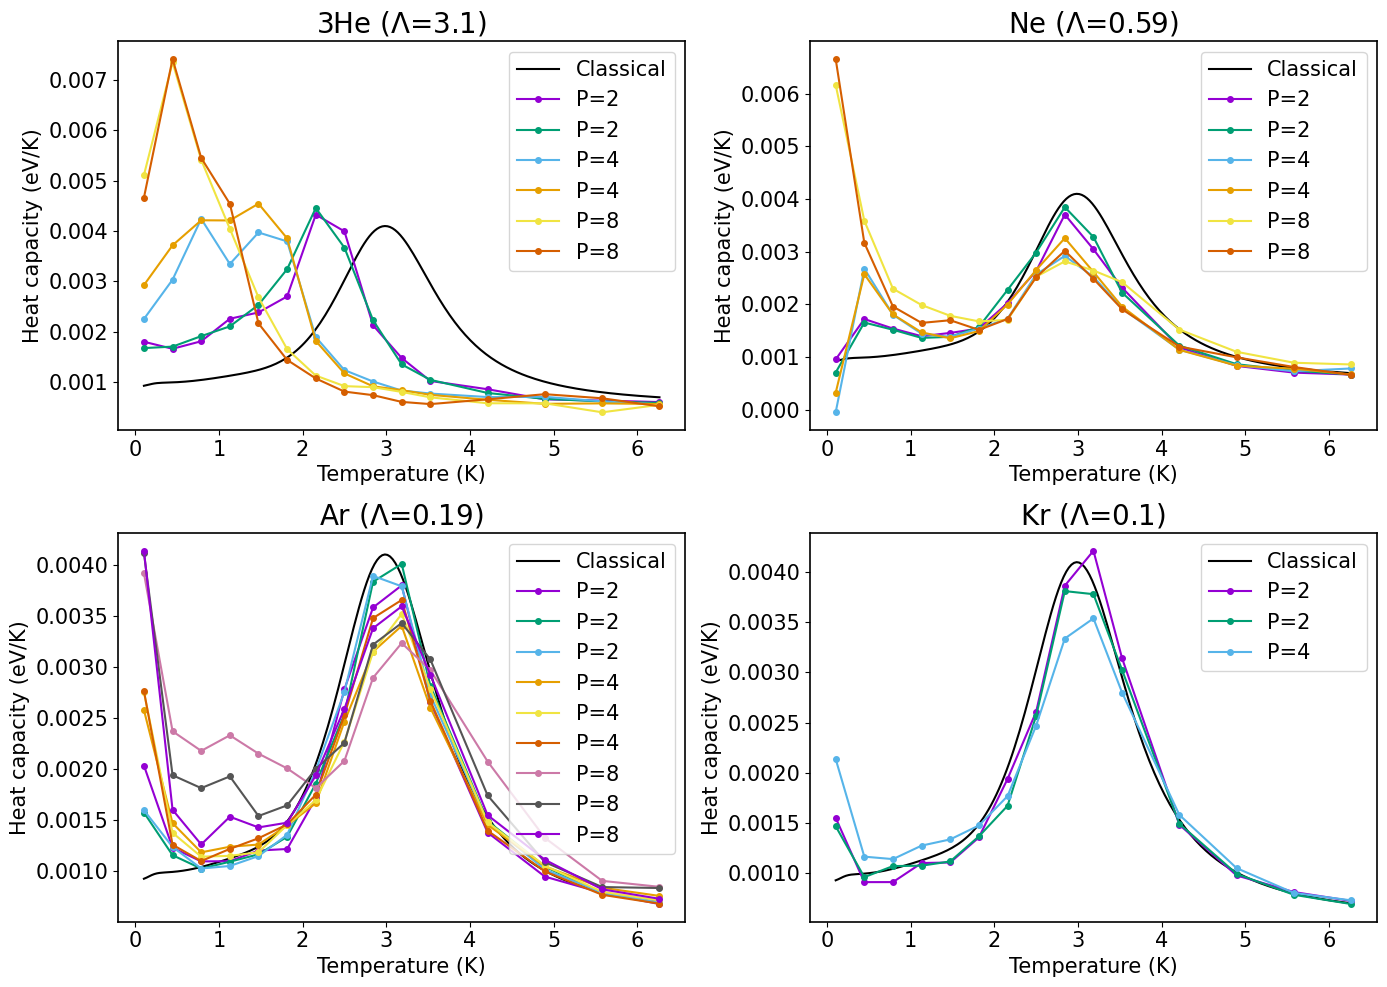

No data found for species Kr, N=6, P=8, K=2000 at /home/dph/nested_fit/test_LJ/cluster/2D_study/../downloads/nested_runs/2D/q_direct/Kr/N6/P8/K2000


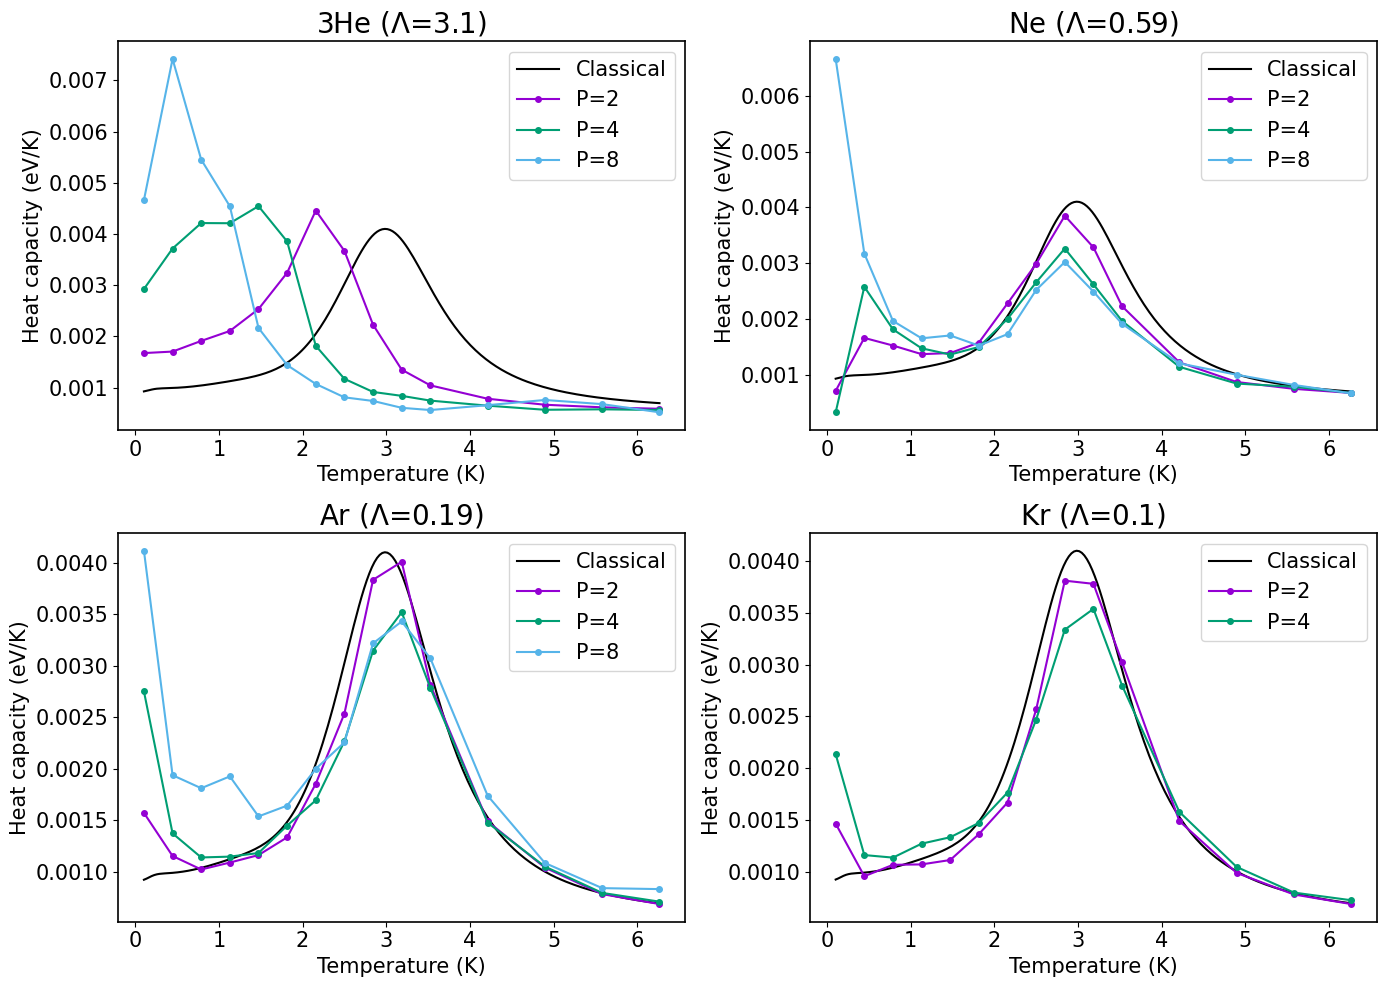

In [30]:
change_units('eV', species=CURRENT_SPECIES)
plot_Cv_dir_grid(path_dir, ['3He', 'Ne', 'Ar', 'Kr'], 6, P_list, K_list, plot_classical=True, path_cls=path_cls, plot_U=False)
plot_Cv_dir_grid(path_dir, ['3He', 'Ne', 'Ar', 'Kr'], 6, P_list, [2000], plot_classical=True, path_cls=path_cls, plot_U=False)

In [31]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

def plot_points_dir_grid(path_dir, N_list, P_list, K_list, replica_number=None):
    # Each combination of (N, P, K) gets one row. There are always 2 columns.
    combos = []
    for N in N_list:
        for P in P_list:
            for K in K_list:
                combos.append((N, P, K))
    
    n_rows = len(combos)
    n_cols = 2
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(6 * n_cols, 5 * n_rows))
    
    # Ensure axes is 2D even if there is only 1 row
    if n_rows == 1:
        axes = np.expand_dims(axes, axis=0)

    for row_idx, (N, P, K) in enumerate(combos):
        # 1. Define Color Maps
        # Using discrete tabs or distinct cmaps helps visibility
        atom_colors_map = plt.cm.hsv(np.linspace(0, 1, N+1))[:-1]
        replica_colors_map = plt.cm.hsv(np.linspace(0, 1, P+1))[:-1]
        
        path_dir_N_P_K = os.path.join(path_dir, f'{CURRENT_SPECIES}/N{N}/P{P}/K{K}')
        
        if os.path.exists(path_dir_N_P_K):
            try:
                # Load Data
                json_path = os.path.join(path_dir_N_P_K, f'tau{tau_list[0]:.3f}', 'nf_output_res.json')
                with open(json_path, 'r') as f:
                    data = json.load(f)
                params = data['params']
                
                # Prepare coordinate lists and both color sets
                coords = []
                c_by_atom = []
                c_by_replica = []
                
                for j in range(1, P + 1):
                    for i in range(1, N + 1):
                        x = params[f'x_{j}_{i}']['max']
                        y = params[f'y_{j}_{i}']['max']
                        if replica_number and j==replica_number:
                            coords.append((x, y))
                            c_by_atom.append(atom_colors_map[i-1])
                            c_by_replica.append(replica_colors_map[j-1])
                        if not replica_number:
                            coords.append((x, y))
                            c_by_atom.append(atom_colors_map[i-1])
                            c_by_replica.append(replica_colors_map[j-1])
                
                x_pts = [p[0] for p in coords]
                y_pts = [p[1] for p in coords]

                # --- Column 1: Colored by Atom ---
                ax_left = axes[row_idx, 0]
                ax_left.scatter(x_pts, y_pts, c=c_by_atom, s=40, alpha=0.7)
                ax_left.set_title(f'N={N}, P={P}, K={K} | Colored by Atom')
                
                # --- Column 2: Colored by Replica ---
                ax_right = axes[row_idx, 1]
                ax_right.scatter(x_pts, y_pts, c=c_by_replica, s=40, alpha=0.7)
                ax_right.set_title(f'N={N}, P={P}, K={K} | Colored by Replica')

            except Exception as e:
                print(f'Error row {row_idx} (N{N}P{P}K{K}): {e}')
        else:
            print(f'Path missing: {path_dir_N_P_K}')

        # Formatting both columns in the row
        for ax in axes[row_idx]:
            ax.set_aspect('equal')
            # ax.vlines((-3, 3), -3, 3, colors='lightgray', linestyles='dashed', alpha=0.5)
            # ax.hlines((-3, 3), -3, 3, colors='lightgray', linestyles='dashed', alpha=0.5)
            ax.set_xlim(-3.5, 3.5)
            ax.set_ylim(-3.5, 3.5)
            ax.set_xlabel('x')
            ax.set_ylabel('y')
    plt.suptitle(rf'{CURRENT_SPECIES} ($\Lambda$={SPECIES_DATA[CURRENT_SPECIES]['Lambda']})')
    plt.tight_layout()
    plt.savefig(os.path.join(root_path, f'points_dir_{CURRENT_SPECIES}_grid'+ (f'_j{replica_number}' if replica_number else '') +'.png'))
    plt.savefig(os.path.join(root_path, f'points_dir_{CURRENT_SPECIES}_grid'+ (f'_j{replica_number}' if replica_number else '') +'.pdf'))
    plt.show()

In [32]:
def plot_points_dir_grid(path_dir, N_list, P_list, K_list):
    combos = []
    for N in N_list:
        for P in P_list:
            for K in K_list:
                combos.append((N, P, K))
    
    n_rows = len(combos)
    n_cols = 2

    plt.close('all')

    # --- Fixed physical sizes (inches) ---
    sq       = 3.2        # main square plot side
    sb_rows  = 4          # number of rows in sidebar
    sb_cell  = sq/sb_rows # each sidebar mini-cell side
    gap_main_sb = 0.15    # gap between main plot and sidebar
    gap_col     = 0.8     # gap between left and right macro-column
    margin_l    = 0.55    # left margin
    margin_r    = 0.25    # right margin
    margin_top  = 0.55    # top margin (for suptitle + col titles)
    margin_bot  = 0.5     # bottom margin

    # Max sidebar columns across all combos (to fix total block width)
    max_sb_cols_n = max(max(int(np.ceil(N / sb_rows)), 1) for N, P, K in combos)
    max_sb_cols_p = max(max(int(np.ceil(P / sb_rows)), 1) for N, P, K in combos)
    max_sb_cols   = max(max_sb_cols_n, max_sb_cols_p)

    sb_width    = max_sb_cols * sb_cell          # fixed sidebar block width
    block_width = sq + gap_main_sb + sb_width    # one macro-column width
    row_height  = sq + 0.45                      # +0.45 for xlabel/title headroom

    fig_w = margin_l + 2 * block_width + gap_col + margin_r
    fig_h = margin_top + n_rows * row_height + (n_rows - 1) * 0.25 + margin_bot

    fig = plt.figure(figsize=(fig_w, fig_h))

    # Convert margins/sizes to figure fractions
    def fx(x): return x / fig_w
    def fy(y): return y / fig_h

    # Column title positions (top of figure, above first row)
    col_centers_x = [
        margin_l + block_width * 0.5,
        margin_l + block_width + gap_col + block_width * 0.5,
    ]
    col_title_y = 1.0 - fy(0.18)
    fig.text(col_centers_x[0] / fig_w, col_title_y, 'Colored by Atom',
             ha='center', va='top', fontsize=12, weight='bold')
    fig.text(col_centers_x[1] / fig_w, col_title_y, 'Colored by Replica',
             ha='center', va='top', fontsize=12, weight='bold')

    for row_idx, (N, P, K) in enumerate(combos):
        atom_colors_map    = plt.cm.hsv(np.linspace(0, 1, N+1))[:-1]
        replica_colors_map = plt.cm.hsv(np.linspace(0, 1, P+1))[:-1]

        path_dir_N_P_K = os.path.join(path_dir, f'{CURRENT_SPECIES}/N{N}/P{P}/K{K}')

        if os.path.exists(path_dir_N_P_K):
            try:
                # first tau, corresponding to lowest temperature, for ground state
                json_path = os.path.join(path_dir_N_P_K, f'tau{tau_list[0]:.3f}', 'nf_output_res.json')
                with open(json_path, 'r') as f:
                    data = json.load(f)
                params = data['params']

                x_grid = np.zeros((P, N))
                y_grid = np.zeros((P, N))
                for j in range(1, P + 1):
                    for i in range(1, N + 1):
                        x_grid[j-1, i-1] = params[f'x_{j}_{i}']['max']
                        y_grid[j-1, i-1] = params[f'y_{j}_{i}']['max']

                x_pts        = x_grid.flatten()
                y_pts        = y_grid.flatten()
                c_by_atom    = [atom_colors_map[i]    for j in range(P) for i in range(N)]
                c_by_replica = [replica_colors_map[j] for j in range(P) for i in range(N)]

                sb_cols_n = max(int(np.ceil(N / sb_rows)), 1)
                sb_cols_p = max(int(np.ceil(P / sb_rows)), 1)

                # Bottom of this row's main square (in inches from bottom of figure)
                row_bot_in = margin_bot + (n_rows - 1 - row_idx) * (row_height + 0.25) + 0.35  # 0.35 for xlabel

                # --- Helper: add axes at exact inch positions ---
                def add_ax_inches(left_in, bot_in, w_in, h_in):
                    return fig.add_axes([fx(left_in), fy(bot_in), fx(w_in), fy(h_in)])

                for col_idx, (sb_cols, colors_map, c_pts, label, grid_x, grid_y, n_items, item_label) in enumerate([
                    (sb_cols_n, atom_colors_map,    c_by_atom,    f'N={N}, P={P}, K={K}',
                     x_grid, y_grid, N, 'A'),
                    (sb_cols_p, replica_colors_map, c_by_replica, f'N={N}, P={P}, K={K}',
                     x_grid, y_grid, P, 'R'),
                ]):
                    col_left_in = margin_l + col_idx * (block_width + gap_col)

                    # Main square plot
                    ax_main = add_ax_inches(col_left_in, row_bot_in, sq, sq)
                    ax_main.scatter(x_pts, y_pts,
                                    c=c_by_atom if col_idx == 0 else c_by_replica,
                                    s=40, alpha=0.6)
                    ax_main.set_xlim(-3.5, 3.5)
                    ax_main.set_ylim(-3.5, 3.5)
                    ax_main.set_aspect('equal', adjustable='box')
                    ax_main.set_title(label, weight='semibold', pad=6, fontsize=9)
                    ax_main.set_xlabel('x', fontsize=8)
                    ax_main.set_ylabel('y', fontsize=8)
                    ax_main.tick_params(labelsize=7)
                    ax_main.grid(True, alpha=0.15)

                    # Sidebar mini-plots — fixed cell size sb_cell x sb_cell
                    sb_left_in = col_left_in + sq + gap_main_sb
                    for item_i in range(n_items):
                        r = item_i % sb_rows
                        c = item_i // sb_rows
                        cell_left = sb_left_in + c * sb_cell
                        cell_bot  = row_bot_in + (sb_rows - 1 - r) * sb_cell  # top-to-bottom

                        ax_inset = add_ax_inches(cell_left, cell_bot, sb_cell, sb_cell)

                        if col_idx == 0:  # atom
                            bg_mask = np.ones(N, dtype=bool); bg_mask[item_i] = False
                            ax_inset.scatter(grid_x[:, bg_mask], grid_y[:, bg_mask],
                                             c='lightgray', s=2, alpha=0.5)
                            ax_inset.scatter(grid_x[:, item_i], grid_y[:, item_i],
                                             color=atom_colors_map[item_i], s=6, alpha=0.9)
                        else:  # replica
                            bg_mask = np.ones(P, dtype=bool); bg_mask[item_i] = False
                            ax_inset.scatter(grid_x[bg_mask, :], grid_y[bg_mask, :],
                                             c='lightgray', s=2, alpha=0.5)
                            ax_inset.scatter(grid_x[item_i, :], grid_y[item_i, :],
                                             color=replica_colors_map[item_i], s=6, alpha=0.9)

                        ax_inset.set_xlim(-3.5, 3.5)
                        ax_inset.set_ylim(-3.5, 3.5)
                        ax_inset.set_aspect('equal', adjustable='box')
                        ax_inset.set_xticks([])
                        ax_inset.set_yticks([])

            except Exception as e:
                print(f'Error row {row_idx} (N{N}P{P}K{K}): {e}')
        else:
            print(f'Path missing: {path_dir_N_P_K}')
            
    Lambda_bf_latex = '\\boldsymbol{\\Lambda}'
    fig.suptitle(rf"{CURRENT_SPECIES} (${Lambda_bf_latex}$={SPECIES_DATA[CURRENT_SPECIES]['Lambda']})",
                 fontsize=13, weight='bold', y=1.0) # or y=1.0 - fy(0.05)
    plt.savefig(os.path.join(root_path, f'points_dir_{CURRENT_SPECIES}_grid.png'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(root_path, f'points_dir_{CURRENT_SPECIES}_grid.pdf'), bbox_inches='tight')
    plt.show()

In [33]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt

def plot_points_dir_grid(path_dir, N_list, P_list, K_list):
    combos = []
    for N in N_list:
        for P in P_list:
            for K in K_list:
                combos.append((N, P, K))
    
    n_rows = len(combos)
    n_cols = 2

    plt.close('all')

    # --- GLOBAL BOUNDARY PRE-SCAN (WITH CENTERING) ---
    # Find the maximum coordinate spread after shifting each system's centroid to (0,0)
    max_coord = 0.0
    for N, P, K in combos:
        path_dir_N_P_K = os.path.join(path_dir, f'{CURRENT_SPECIES}/N{N}/P{P}/K{K}')
        if os.path.exists(path_dir_N_P_K):
            try:
                json_path = os.path.join(path_dir_N_P_K, f'tau{tau_list[0]:.3f}', 'nf_output_res.json')
                with open(json_path, 'r') as f:
                    data = json.load(f)
                params = data['params']
                
                x_vals = []
                y_vals = []
                for j in range(1, P + 1):
                    for i in range(1, N + 1):
                        x_vals.append(params[f'x_{j}_{i}']['max'])
                        y_vals.append(params[f'y_{j}_{i}']['max'])
                
                # Compute centroid for this specific configuration
                cx = np.mean(x_vals)
                cy = np.mean(y_vals)
                
                # Check maximum distance from center across both coordinates
                max_coord = max(max_coord, np.max(np.abs(np.array(x_vals) - cx)), np.max(np.abs(np.array(y_vals) - cy)))
            except Exception:
                pass

    # Fallback if file scanning fails, otherwise pad slightly (8%)
    max_val = 3.5 if max_coord == 0.0 else max_coord * 2

    # --- Fixed physical sizes (inches) ---
    sq       = 3.2        # main square plot side
    sb_rows  = 4          # number of rows in sidebar
    sb_cell  = sq/sb_rows # each sidebar mini-cell side
    gap_main_sb = 0.15    # gap between main plot and sidebar
    gap_col     = 0.8     # gap between left and right macro-column
    margin_l    = 0.55    # left margin
    margin_r    = 0.25    # right margin
    margin_top  = 0.55    # top margin (for suptitle + col titles)
    margin_bot  = 0.5     # bottom margin

    # Max sidebar columns across all combos (to fix total block width)
    max_sb_cols_n = max(max(int(np.ceil(N / sb_rows)), 1) for N, P, K in combos)
    max_sb_cols_p = max(max(int(np.ceil(P / sb_rows)), 1) for N, P, K in combos)
    max_sb_cols   = max(max_sb_cols_n, max_sb_cols_p)

    sb_width    = max_sb_cols * sb_cell          # fixed sidebar block width
    block_width = sq + gap_main_sb + sb_width    # one macro-column width
    row_height  = sq + 0.45                      # +0.45 for xlabel/title headroom

    fig_w = margin_l + 2 * block_width + gap_col + margin_r
    fig_h = margin_top + n_rows * row_height + (n_rows - 1) * 0.25 + margin_bot

    fig = plt.figure(figsize=(fig_w, fig_h))

    def fx(x): return x / fig_w
    def fy(y): return y / fig_h

    # Column title positions
    col_centers_x = [
        margin_l + block_width * 0.5,
        margin_l + block_width + gap_col + block_width * 0.5,
    ]
    col_title_y = 1.0 - fy(0.18)
    fig.text(col_centers_x[0] / fig_w, col_title_y, 'Colored by Atom',
             ha='center', va='top', fontsize=16, weight='bold')
    fig.text(col_centers_x[1] / fig_w, col_title_y, 'Colored by Replica',
             ha='center', va='top', fontsize=16, weight='bold')

    for row_idx, (N, P, K) in enumerate(combos):
        atom_colors_map    = plt.cm.hsv(np.linspace(0, 1, N+1))[:-1]
        replica_colors_map = plt.cm.hsv(np.linspace(0, 1, P+1))[:-1]

        path_dir_N_P_K = os.path.join(path_dir, f'{CURRENT_SPECIES}/N{N}/P{P}/K{K}')

        if os.path.exists(path_dir_N_P_K):
            try:
                json_path = os.path.join(path_dir_N_P_K, f'tau{tau_list[0]:.3f}', 'nf_output_res.json')
                with open(json_path, 'r') as f:
                    data = json.load(f)
                params = data['params']

                x_grid = np.zeros((P, N))
                y_grid = np.zeros((P, N))
                for j in range(1, P + 1):
                    for i in range(1, N + 1):
                        x_grid[j-1, i-1] = params[f'x_{j}_{i}']['max']
                        y_grid[j-1, i-1] = params[f'y_{j}_{i}']['max']

                # --- CENTERING CALCULATION ---
                # Subtract the system mean to center the cluster exactly at (0,0)
                x_center = np.mean(x_grid)
                y_center = np.mean(y_grid)
                x_grid -= x_center
                y_grid -= y_center

                x_pts        = x_grid.flatten()
                y_pts        = y_grid.flatten()
                c_by_atom    = [atom_colors_map[i]    for j in range(P) for i in range(N)]
                c_by_replica = [replica_colors_map[j] for j in range(P) for i in range(N)]

                sb_cols_n = max(int(np.ceil(N / sb_rows)), 1)
                sb_cols_p = max(int(np.ceil(P / sb_rows)), 1)

                row_bot_in = margin_bot + (n_rows - 1 - row_idx) * (row_height + 0.25) + 0.35

                def add_ax_inches(left_in, bot_in, w_in, h_in):
                    return fig.add_axes([fx(left_in), fy(bot_in), fx(w_in), fy(h_in)])

                for col_idx, (sb_cols, colors_map, c_pts, label, grid_x, grid_y, n_items, item_label) in enumerate([
                    (sb_cols_n, atom_colors_map,    c_by_atom,    f'N={N}, P={P}, K={K}',
                     x_grid, y_grid, N, 'A'),
                    (sb_cols_p, replica_colors_map, c_by_replica, f'N={N}, P={P}, K={K}',
                     x_grid, y_grid, P, 'R'),
                ]):
                    col_left_in = margin_l + col_idx * (block_width + gap_col)

                    # Main square plot (centered coordinates)
                    ax_main = add_ax_inches(col_left_in, row_bot_in, sq, sq)
                    ax_main.scatter(x_pts, y_pts,
                                    c=c_by_atom if col_idx == 0 else c_by_replica,
                                    s=40, alpha=0.6)
                    ax_main.set_xlim(-max_val, max_val)
                    ax_main.set_ylim(-max_val, max_val)
                    ax_main.set_aspect('equal', adjustable='box')
                    # ax_main.set_title(label, weight='semibold', pad=6, fontsize=9)
                    ax_main.set_xlabel('x', fontsize=8)
                    ax_main.set_ylabel('y', fontsize=8)
                    ax_main.tick_params(labelsize=7)
                    ax_main.grid(True, alpha=0.15)

                    # Sidebar mini-plots (centered coordinates)
                    sb_left_in = col_left_in + sq + gap_main_sb
                    for item_i in range(n_items):
                        r = item_i % sb_rows
                        c = item_i // sb_rows
                        cell_left = sb_left_in + c * sb_cell
                        cell_bot  = row_bot_in + (sb_rows - 1 - r) * sb_cell

                        ax_inset = add_ax_inches(cell_left, cell_bot, sb_cell, sb_cell)

                        if col_idx == 0:  # atom
                            bg_mask = np.ones(N, dtype=bool); bg_mask[item_i] = False
                            ax_inset.scatter(grid_x[:, bg_mask], grid_y[:, bg_mask],
                                             c='lightgray', s=2, alpha=0.5)
                            ax_inset.scatter(grid_x[:, item_i], grid_y[:, item_i],
                                             color=atom_colors_map[item_i], s=6, alpha=0.9)
                        else:  # replica
                            bg_mask = np.ones(P, dtype=bool); bg_mask[item_i] = False
                            ax_inset.scatter(grid_x[bg_mask, :], grid_y[bg_mask, :],
                                             c='lightgray', s=2, alpha=0.5)
                            ax_inset.scatter(grid_x[item_i, :], grid_y[item_i, :],
                                             color=replica_colors_map[item_i], s=6, alpha=0.9)

                        ax_inset.set_xlim(-max_val, max_val)
                        ax_inset.set_ylim(-max_val, max_val)
                        ax_inset.set_aspect('equal', adjustable='box')
                        ax_inset.set_xticks([])
                        ax_inset.set_yticks([])

            except Exception as e:
                print(f'Error row {row_idx} (N{N}P{P}K{K}): {e}')
        else:
            print(f'Path missing: {path_dir_N_P_K}')
            
    Lambda_bf_latex = '\\boldsymbol{\\Lambda}'
    # fig.suptitle(rf"{CURRENT_SPECIES} (${Lambda_bf_latex}$={SPECIES_DATA[CURRENT_SPECIES]['Lambda']})",
    #              fontsize=13, weight='bold', y=1.0)
    plt.savefig(os.path.join(root_path, f'points_dir_{CURRENT_SPECIES}_grid.png'), dpi=300, bbox_inches='tight')
    plt.savefig(os.path.join(root_path, f'points_dir_{CURRENT_SPECIES}_grid.pdf'), bbox_inches='tight')
    plt.show()

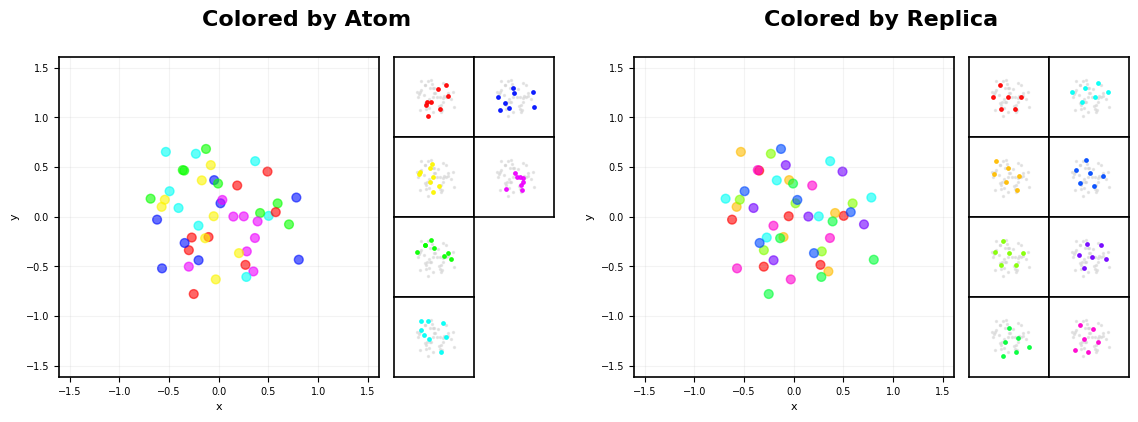

In [34]:
# plot_points_dir_grid(path_dir, [N], P_list, K_list)
plot_points_dir_grid(path_dir, [N], [8], [2000])